## 1. Data Loading and First Look

In [1]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [2]:
print("\n" + "="*60)
print("CREATING PROJECT DIRECTORY STRUCTURE")
print("="*60)

# Creating directories
directories = [
    '../data',
    '../notebooks'
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"✓ Created: {directory}")

print("\n✅ Directory structure created!")


CREATING PROJECT DIRECTORY STRUCTURE
✓ Created: ../data
✓ Created: ../notebooks

✅ Directory structure created!


In [3]:
# Setting display and styling options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Downloading dataset using kagglehub
path = kagglehub.dataset_download("samuelsemaya/e-commerce-customer-churn")
print("Path to the dataset:", path)

# Listing files in the path 
import os
files = os.listdir(path)
print(f"\nFiles in dataset: {files}")

# Loading the data
csv_file = [f for f in files if f.endswith('.csv')][0]
churn_df = pd.read_csv(os.path.join(path, csv_file))

print(f"\n{'='*50}")
print(f"DATASET LOADED SUCCESSFULLY")
print(f"{'='*50}\n")

# Basic information about the dataset
print(f"Shape: {churn_df.shape}")
print(f"Rows: {churn_df.shape[0]:,}")
print(f"Columns: {churn_df.shape[1]:,}")

Path to the dataset: C:\Users\OlkaSz\.cache\kagglehub\datasets\samuelsemaya\e-commerce-customer-churn\versions\3

Files in dataset: ['confussion_matrix.png', 'customer_predictor_app.png', 'data_ecommerce_customer_churn.csv', 'e-commerce_churn.png', 'final_model.sav', 'logo_shopwise.png']

DATASET LOADED SUCCESSFULLY

Shape: (3941, 11)
Rows: 3,941
Columns: 11


In [4]:
print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
churn_df.head()


FIRST 5 ROWS


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## 2. Data Quality Check

In [5]:
# Column names and types
print("\n" + "="*50)
print("COLUMN INFORMATION")
print("="*50)
churn_df.info()


COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [6]:
# Checking column names
print("\n" + "="*50)
print("ACTUAL COLUMN NAMES")
print("="*50)
print(churn_df.columns.tolist())


ACTUAL COLUMN NAMES
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


In [7]:
# Re-naming to snake_case standard
renamed_columns = {
    'Tenure': 'tenure',
    'WarehouseToHome': 'warehouse_to_home',
    'NumberOfDeviceRegistered': 'num_devices_registered',
    'PreferedOrderCat': 'preferred_order_category',
    'SatisfactionScore': 'satisfaction_score',
    'MaritalStatus': 'marital_status',
    'NumberOfAddress': 'num_addresses',
    'Complain': 'has_complained',
    'DaySinceLastOrder': 'days_since_last_order',
    'CashbackAmount': 'cashback_amount',
    'Churn': 'churn'
}

churn_df.rename(columns=renamed_columns, inplace=True)
churn_df.head(10)

,tenure,warehouse_to_home,num_devices_registered,preferred_order_category,satisfaction_score,marital_status,num_addresses,has_complained,days_since_last_order,cashback_amount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0
6,1.0,15.0,6,Mobile Phone,5,Divorced,3,0,2.0,149.51,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
9,17.0,7.0,3,Laptop & Accessory,1,Married,5,1,2.0,157.43,0


## 2.1. Checking duplicates

In [8]:
# Checking for duplicates
print("\n" + "="*50)
print("🔍 CHECKING FOR DUPLICATE RECORDS")
print("="*50)

# Dataset before duplicate check
print(f"Original dataset shape: {churn_df.shape}")
print(f"Total rows: {len(churn_df):,}")

# Checking for duplicates (all columns identical)
duplicates_all = churn_df.duplicated().sum()

print(f"\nExact duplicate rows (all columns identical): {duplicates_all}")

if duplicates_all > 0:
    print(f"\n⚠️ Found {duplicates_all} exact duplicate rows ({duplicates_all/len(churn_df)*100:.1f}% of data)")

    # Showing example of duplicates
    print("Example duplicate (first occurance):")
    duplicate_rows = churn_df[churn_df.duplicated(keep=False)]
    print(duplicate_rows.head(2))

    # Removing duplicates
    print("\nRemoving duplicates (keeping first occurance)...")
    rows_before = len(churn_df)
    churn_df = churn_df.drop_duplicates(keep='first')
    rows_after = len(churn_df)
    rows_removed = rows_before - rows_after

    print(f"✓ Removed {rows_removed:,} duplicate rows")
    print(f"✓ Dataset after deduplication: {churn_df.shape}")
else:
    print(f"✓ No exact duplicates found - all rows are qunique!")

print("\n" + "="*60)
print(f"📊 DEDUPLICATED DATASET: {churn_df.shape[0]:,} rows x {churn_df.shape[1]} columns")
print("="*60)


🔍 CHECKING FOR DUPLICATE RECORDS
Original dataset shape: (3941, 11)
Total rows: 3,941

Exact duplicate rows (all columns identical): 671

⚠️ Found 671 exact duplicate rows (17.0% of data)
Example duplicate (first occurance):
   tenure  warehouse_to_home  num_devices_registered preferred_order_category  \
4    30.0               15.0                       4                   Others   
7     1.0               11.0                       4             Mobile Phone   

   satisfaction_score marital_status  num_addresses  has_complained  \
4                   4         Single              8               0   
7                   5         Single              3               0   

   days_since_last_order  cashback_amount  churn  
4                    8.0           322.17      0  
7                    1.0           154.73      1  

Removing duplicates (keeping first occurance)...
✓ Removed 671 duplicate rows
✓ Dataset after deduplication: (3270, 11)

📊 DEDUPLICATED DATASET: 3,270 rows x 11 c

## 2.2. Ivestigating missing values

In [9]:
# Inspecting missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)

missing = pd.DataFrame({
    'Column': churn_df.columns,
    'Missing_Count': churn_df.isnull().sum(),
    'Missing_Percent': (churn_df.isnull().sum() / len(churn_df) * 100).round(2)
})
missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing) > 0:
    print(missing)
else:
    print("✓ No missing values found!")


MISSING VALUES
                                      Column  Missing_Count  Missing_Percent
days_since_last_order  days_since_last_order            181             5.54
tenure                                tenure            160             4.89
warehouse_to_home          warehouse_to_home            135             4.13


## 2.3. Discovering patterns for missing values

In [10]:
print("\n" + "="*60)
print("INVESTIGATING MISSING days_since_last_order PATTERNS")
print("="*60)

# Creating a flag to identify missing rows
churn_df['days_missing_flag'] = churn_df['days_since_last_order'].isnull().astype(int)

# Splitting into two groups
has_missing = churn_df[churn_df['days_missing_flag'] == 1]
no_missing = churn_df[churn_df['days_missing_flag'] == 0]
print(f"\nRows with missing days_since_last_order: {len(has_missing)} ({len(has_missing)/len(churn_df)*100:.1f}%)")
print(f"Rows without missing: {len(no_missing)} ({len(no_missing)/len(churn_df)*100:.1f}%)")

# Comparing key characteristics
print("\n" + "="*60)
print("COMPARISON: Missing vs Non-Missing")
print("="*60)

comparison = pd.DataFrame({
    'Feature': ['tenure', 'warehouse_to_home', 'num_devices_registered', 
                'satisfaction_score', 'num_addresses', 'has_complained', 
                'cashback_amount', 'CHURN RATE'],
    'Missing days_since_last_order': [
        has_missing['tenure'].mean(),
        has_missing['warehouse_to_home'].mean(),
        has_missing['num_devices_registered'].mean(),
        has_missing['satisfaction_score'].mean(),
        has_missing['num_addresses'].mean(),
        has_missing['has_complained'].mean(),
        has_missing['cashback_amount'].mean(),
        has_missing['churn'].mean()
    ],
    'Not Missing': [
        no_missing['tenure'].mean(),
        no_missing['warehouse_to_home'].mean(),
        no_missing['num_devices_registered'].mean(),
        no_missing['satisfaction_score'].mean(),
        no_missing['num_addresses'].mean(),
        no_missing['has_complained'].mean(),
        no_missing['cashback_amount'].mean(),
        no_missing['churn'].mean()
    ]
})

comparison['Difference'] = comparison['Missing days_since_last_order'] - comparison['Not Missing']
print(comparison.round(2))


INVESTIGATING MISSING days_since_last_order PATTERNS

Rows with missing days_since_last_order: 181 (5.5%)
Rows without missing: 3089 (94.5%)

COMPARISON: Missing vs Non-Missing
                  Feature  Missing days_since_last_order  Not Missing  \
0                  tenure                          11.81        10.09   
1       warehouse_to_home                          15.72        15.50   
2  num_devices_registered                           4.08         3.65   
3      satisfaction_score                           2.88         3.03   
4           num_addresses                           4.85         4.19   
5          has_complained                           0.26         0.28   
6         cashback_amount                         220.98       174.87   
7              CHURN RATE                           0.17         0.16   

   Difference  
0        1.72  
1        0.22  
2        0.42  
3       -0.14  
4        0.66  
5       -0.02  
6       46.11  
7        0.00  


In [11]:
print("\n" + "="*60)
print("🔬 TESTING HYPOTHESIS: Missing days_since_last_order = Dormant Customers")
print("="*60)

# Investigating the MAX days for customers who HAVE the value for days_since_last_order
has_days = churn_df[churn_df['days_since_last_order'].notnull()]
max_days = has_days['days_since_last_order'].max()
p95_days = has_days['days_since_last_order'].quantile(0.95)
p99_days = has_days['days_since_last_order'].quantile(0.99)
median_days = has_days['days_since_last_order'].median()

print(f"\ndays_since_last_order distribution (non-missing):")
print(f"  Median: {median_days:.0f} days")
print(f"  95th percentile: {p95_days:.0f} days")
print(f"  99th percentile: {p99_days:.0f} days")
print(f"  Maximum: {max_days:.0f} days")

# Comparing missing vs high-recency customers
print("\n" + "="*60)
print("Comparing Missing vs Very Dormant (top 5% days)")
print("="*60)

missing_days = churn_df[churn_df['days_since_last_order'].isnull()]
very_dormant = churn_df[churn_df['days_since_last_order'] >= p95_days]

comparison = pd.DataFrame({
    'Metric': ['Count', 'Tenure (avg)', 'Cashback (avg)', 'Churn Rate (%)'],
    'Missing': [
        len(missing_days),
        missing_days['tenure'].mean(),
        missing_days['cashback_amount'].mean(),
        missing_days['churn'].mean() * 100
    ],
    'Very Dormant (95%+)': [
        len(very_dormant),
        very_dormant['tenure'].mean(),
        very_dormant['cashback_amount'].mean(),
        very_dormant['churn'].mean() * 100
    ]
})

print(comparison.round(2))

# Checking if they are similar
print(f"\n" + "="*60)
print("HYPOTHESIS TEST")
print("="*60)

tenure_diff = abs(missing_days['tenure'].mean() - very_dormant['tenure'].mean())
churn_diff = abs(missing_days['churn'].mean() - very_dormant['churn'].mean()) * 100

print(f"\nSimilarity between Missing and Very Dormant:")
print(f"  Tenure difference: {tenure_diff:.1f} months")
print(f"  Churn rate difference: {churn_diff:.1f}%")

if tenure_diff < 3 and churn_diff < 5:
    print(f"\n✅ HYPOTHESIS CONFIRMED!")
    print(f"   Missing days_since_last_order likely represents EXTREME dormancy")
    print(f"   → Recommend filling with MAX ({max_days:.0f} days) or even higher")
    fill_strategy = "max_or_higher"
else:
    print(f"\n❌ HYPOTHESIS NOT SUPPORTED")
    print(f"   Missing days customers are DIFFERENT from very dormant")
    print(f"   → Recommend filling with median ({median_days:.0f} days)")
    fill_strategy = "median"



🔬 TESTING HYPOTHESIS: Missing days_since_last_order = Dormant Customers

days_since_last_order distribution (non-missing):
  Median: 3 days
  95th percentile: 11 days
  99th percentile: 15 days
  Maximum: 46 days

Comparing Missing vs Very Dormant (top 5% days)
           Metric  Missing  Very Dormant (95%+)
0           Count   181.00               168.00
1    Tenure (avg)    11.81                15.02
2  Cashback (avg)   220.98               226.82
3  Churn Rate (%)    16.57                 5.36

HYPOTHESIS TEST

Similarity between Missing and Very Dormant:
  Tenure difference: 3.2 months
  Churn rate difference: 11.2%

❌ HYPOTHESIS NOT SUPPORTED
   Missing days customers are DIFFERENT from very dormant
   → Recommend filling with median (3 days)



Distribution Analysis


C:\Users\OlkaSz\AppData\Local\Temp\ipykernel_24884\1829535142.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = has_days_copy.groupby('days_bin')['churn'].agg(['mean', 'count'])


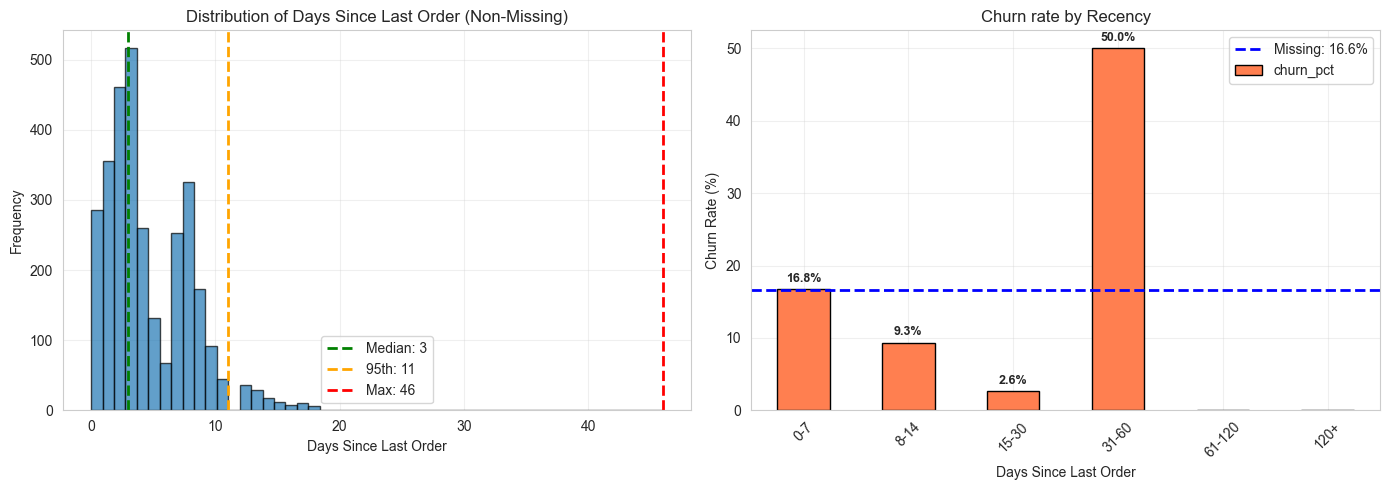

In [12]:
# Visualizing distribution analysis
print(f"\n" + "="*60)
print("Distribution Analysis")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Dsitribution of days (non-missing)
plt.subplot(1, 2, 1)
plt.hist(has_days['days_since_last_order'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(median_days, color='green', linestyle='--', linewidth=2, label=f'Median: {median_days:.0f}')
plt.axvline(p95_days, color='orange', linestyle='--', linewidth=2, label=f'95th: {p95_days:.0f}')
plt.axvline(max_days, color='red', linestyle='--', linewidth=2, label=f'Max: {max_days:.0f}')
plt.xlabel('Days Since Last Order')
plt.ylabel('Frequency')
plt.title('Distribution of Days Since Last Order (Non-Missing)')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Churn rate by days_since_last_order bins
plt.subplot(1, 2, 2)
has_days_copy = has_days.copy()
has_days_copy['days_bin'] = pd.cut(has_days_copy['days_since_last_order'],
                                   bins =[0, 7, 14, 30, 60, 120, 1000],
                                   labels=['0-7', '8-14', '15-30', '31-60', '61-120', '120+'])

churn_by_bin = has_days_copy.groupby('days_bin')['churn'].agg(['mean', 'count'])
churn_by_bin['churn_pct'] = churn_by_bin['mean'] * 100

churn_by_bin['churn_pct'].plot(kind='bar', color='coral', edgecolor='black')
plt.axhline(y=missing_days['churn'].mean()*100, color='blue', linestyle='--',
            linewidth=2, label=f'Missing: {missing_days["churn"].mean()*100:.1f}%')
plt.xlabel('Days Since Last Order')
plt.ylabel('Churn Rate (%)')
plt.title('Churn rate by Recency')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, v in enumerate(churn_by_bin['churn_pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

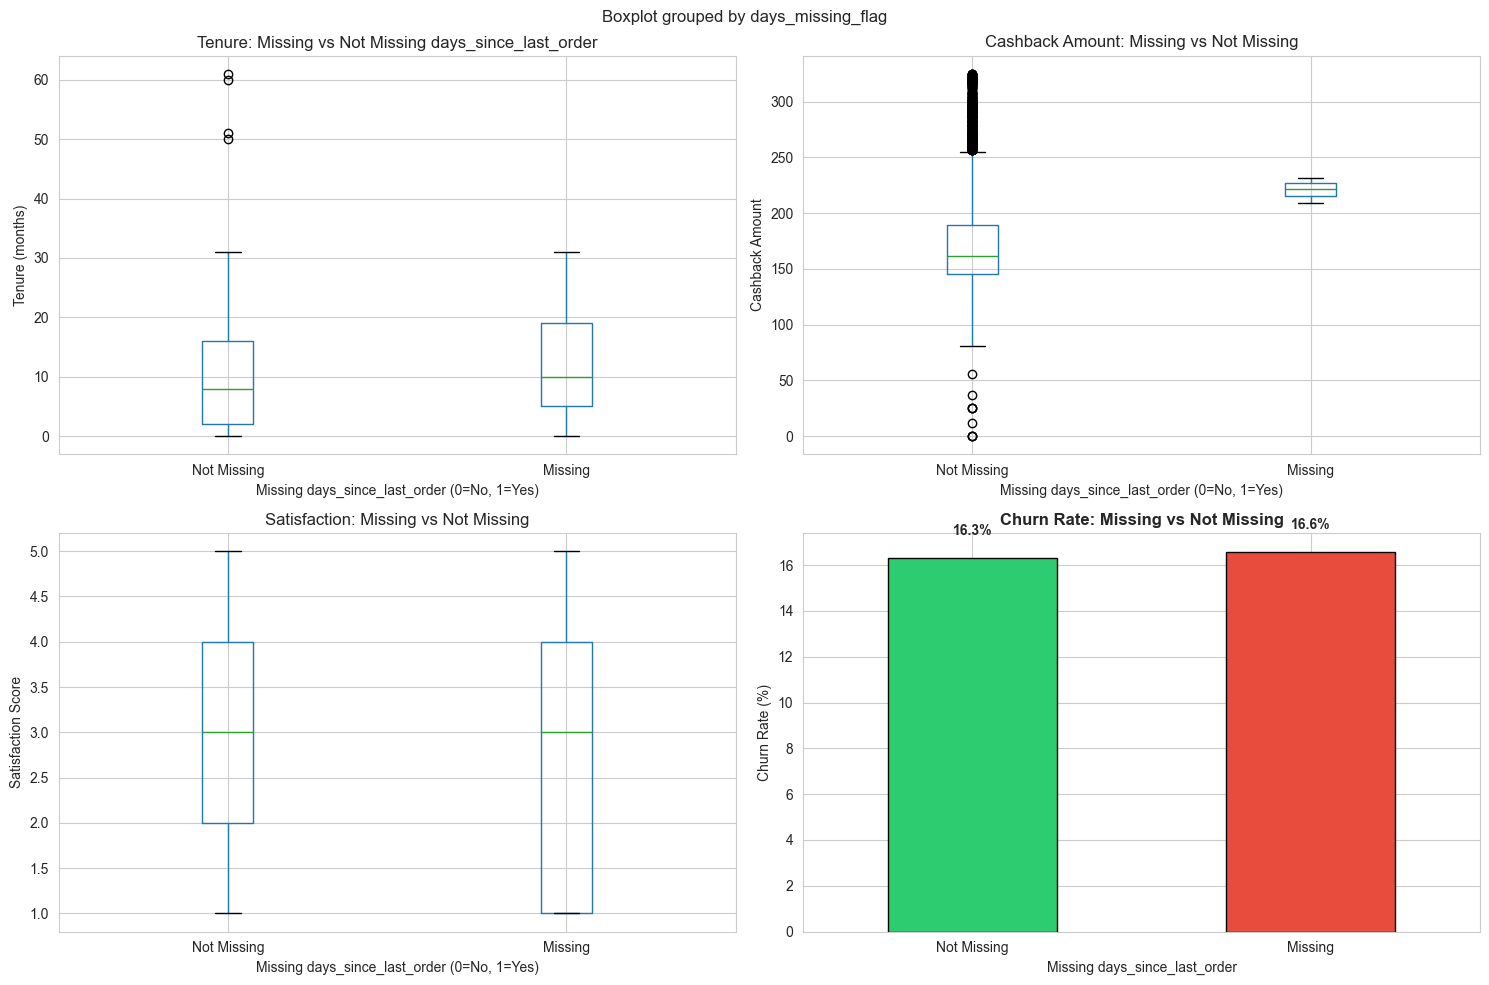

In [13]:
# Visualizing key differences
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tenure comparison
ax1 = axes[0, 0]
churn_df.boxplot(column='tenure', by='days_missing_flag', ax=ax1)
ax1.set_title('Tenure: Missing vs Not Missing days_since_last_order')
ax1.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax1.set_ylabel('Tenure (months)')
plt.sca(ax1)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 2. Cashback comparison
ax2 = axes[0, 1]
churn_df.boxplot(column='cashback_amount', by='days_missing_flag', ax=ax2)
ax2.set_title('Cashback Amount: Missing vs Not Missing')
ax2.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax2.set_ylabel('Cashback Amount')
plt.sca(ax2)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 3. Satisfaction comparison
ax3 = axes[1, 0]
churn_df.boxplot(column='satisfaction_score', by='days_missing_flag', ax=ax3)
ax3.set_title('Satisfaction: Missing vs Not Missing')
ax3.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax3.set_ylabel('Satisfaction Score')
plt.sca(ax3)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 4. Churn rate comparison
ax4 = axes[1, 1]
churn_comparison = churn_df.groupby('days_missing_flag')['churn'].mean() * 100
churn_comparison.plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax4.set_title('Churn Rate: Missing vs Not Missing', fontweight='bold')
ax4.set_xlabel('Missing days_since_last_order')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_xticklabels(['Not Missing', 'Missing'], rotation=0)

# Adding value labels
for i, v in enumerate(churn_comparison):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.4. Filling out missing values

In [14]:
print("\n" + "="*60)
print("📝 FILLING MISSING days_since_last_order")
print("="*60)

# Counting missing values before
missing_before = churn_df['days_since_last_order'].isna().sum()
print(f"\n✓ Missing values before: {missing_before} ({missing_before/len(churn_df)*100:.1f})%")

# Getting median from non-missing values
median_days = churn_df['days_since_last_order'].median()
print(f"✓ Median days_since_last_order: {median_days:.0f} days")

# Filling out missing values with median
churn_df['days_since_last_order'] = churn_df['days_since_last_order'].fillna(median_days)

# Veryfying no missing values
missing_after = churn_df['days_since_last_order'].isna().sum()
print(f"✓  Missing values after: {missing_after}")

# Checking fill-in strategy
if missing_after == 0:
    print(f"\n ✅ SUCCESS: All {missing_before} missing values filled with median ({median_days:.0f} days)")
else:
    print(f"\n ⚠️ WARNING: Still have {missing_after} missing values")
print("="*60)


📝 FILLING MISSING days_since_last_order

✓ Missing values before: 181 (5.5)%
✓ Median days_since_last_order: 3 days
✓  Missing values after: 0

 ✅ SUCCESS: All 181 missing values filled with median (3 days)


In [16]:
print("\n" + "="*60)
print("INVESTIGATING MISSING tenure PATTERNS")
print("="*60)

# Creating flag
churn_df['tenure_missing_flag'] = churn_df['tenure'].isnull().astype(int)

# Spliting groups
has_tenure_missing = churn_df[churn_df['tenure_missing_flag'] == 1]
no_tenure_missing = churn_df[churn_df['tenure_missing_flag'] == 0]
print(f"\nRows with missing tenure: {len(has_tenure_missing)} ({len(has_tenure_missing)/len(churn_df)*100:.1f}%)")
print(f"Rows without missing: {len(no_tenure_missing)} ({len(no_tenure_missing)/len(churn_df)*100:.1f}%)")

# Comparing characteristics
print("\n" + "="*60)
print("COMPARISON: Missing tenure vs Non-Missing")
print("="*60)

tenure_comparison = pd.DataFrame({
    'Feature': ['days_since_last_order', 'warehouse_to_home', 'num_devices_registered', 
                'satisfaction_score', 'num_addresses', 'has_complained', 
                'cashback_amount', 'CHURN RATE'],
    'Missing Tenure': [
        has_tenure_missing['days_since_last_order'].mean(),
        has_tenure_missing['warehouse_to_home'].mean(),
        has_tenure_missing['num_devices_registered'].mean(),
        has_tenure_missing['satisfaction_score'].mean(),
        has_tenure_missing['num_addresses'].mean(),
        has_tenure_missing['has_complained'].mean(),
        has_tenure_missing['cashback_amount'].mean(),
        has_tenure_missing['churn'].mean()
    ],
    'Not Missing': [
        no_tenure_missing['days_since_last_order'].mean(),
        no_tenure_missing['warehouse_to_home'].mean(),
        no_tenure_missing['num_devices_registered'].mean(),
        no_tenure_missing['satisfaction_score'].mean(),
        no_tenure_missing['num_addresses'].mean(),
        no_tenure_missing['has_complained'].mean(),
        no_tenure_missing['cashback_amount'].mean(),
        no_tenure_missing['churn'].mean()
    ]
})

tenure_comparison['Difference'] = tenure_comparison['Missing Tenure'] - tenure_comparison['Not Missing']
print(tenure_comparison.round(2))


INVESTIGATING MISSING tenure PATTERNS

Rows with missing tenure: 160 (4.9%)
Rows without missing: 3110 (95.1%)

COMPARISON: Missing tenure vs Non-Missing
                  Feature  Missing Tenure  Not Missing  Difference
0   days_since_last_order            2.14         4.58       -2.44
1       warehouse_to_home           14.41        15.57       -1.16
2  num_devices_registered            3.24         3.70       -0.46
3      satisfaction_score            3.10         3.02        0.08
4           num_addresses            3.19         4.28       -1.08
5          has_complained            0.26         0.28       -0.02
6         cashback_amount          120.41       180.35      -59.94
7              CHURN RATE            0.30         0.16        0.14


In [17]:
print("\n" + "="*60)
print("HANDLING MISSING tenure")
print("="*60)

# Filling with 0 (they are new customers)
churn_df['tenure'] = churn_df['tenure'].fillna(0)

print("✓ tenure: Filled with 0 (new customers)")
print(f"  - Flag already created for {churn_df['tenure_missing_flag'].sum()} originally missing values")

# Verifying the imputation - separating into 3 groups
print("\nVerification: - Three Distinct Groups:")
print("="*60)

missing_tenure = churn_df[churn_df['tenure_missing_flag'] == 1]
brand_new = churn_df[(churn_df['tenure'] == 0) & (churn_df['tenure_missing_flag'] == 0)]
has_tenure = churn_df[churn_df['tenure'] > 0]

print(f"1. Originally Missing (now filled -> 0): {len(missing_tenure):>4} ({missing_tenure['churn'].mean()*100:>5.1f}% churn)")
print(f"2. Brand New (tenure=0 orignally):       {len(brand_new):>4} ({brand_new['churn'].mean()*100:>5.1f}% churn)")
print(f"3. Has Tenure (> 0 months):              {len(has_tenure):>4} ({has_tenure['churn'].mean()*100:>5.1f}% churn)")

print("\n" + "="*60)
print("🔥 THREE DISTINCT RISK PROFILES")
print("="*60)

# calculating the dramatic difference
brand_new_churn = brand_new['churn'].mean() * 100
missing_churn = missing_tenure['churn'].mean() * 100
established_churn = has_tenure[has_tenure['tenure'] >= 7]['churn'].mean() * 100

print(f"TRUE BRAND NEW (0mo):               {brand_new_churn:>5.1f}% churn - HIGHEST RISK")
print(f"MISSING TENURE (data gap):          {missing_churn:>5.1f}% churn — ELEVATED RISK") 
print(f"ESTABLISHED (7+mo):                 {established_churn:>5.1f}% churn")

# Ivestigating missing tenure group
missing_churn = missing_tenure['churn'].mean() * 100
print(f"\nOriginally missing tenure:       {missing_churn:.1f}% churn")
if missing_churn > brand_new_churn:
    print(f"→ Missing tenure customers are likely DORMANT (even higher churn!)")
else:
    print(f"→ Missing tenure have a lower churn than brand new, but still elevated risk")

print("="*60)



HANDLING MISSING tenure
✓ tenure: Filled with 0 (new customers)
  - Flag already created for 160 originally missing values

Verification: - Three Distinct Groups:
1. Originally Missing (now filled -> 0):  160 ( 30.0% churn)
2. Brand New (tenure=0 orignally):        282 ( 54.3% churn)
3. Has Tenure (> 0 months):              2828 ( 11.8% churn)

🔥 THREE DISTINCT RISK PROFILES
TRUE BRAND NEW (0mo):                54.3% churn - HIGHEST RISK
MISSING TENURE (data gap):           30.0% churn — ELEVATED RISK
ESTABLISHED (7+mo):                   4.8% churn

Originally missing tenure:       30.0% churn
→ Missing tenure have a lower churn than brand new, but still elevated risk



🔥 CRITICAL INSIGHT: CUSTOMER TENURE & CHURN RISK

Churn Rate by Customer Tenure:
                 count  churn_pct
tenure_segment                   
Brand New (0mo)    282       54.3
1-3 months         621       35.1
4-6 months         369        7.0
7-12 months        751        5.5
1-2 years          831        5.8
2+ years           256        0.0
Missing Tenure     160       30.0


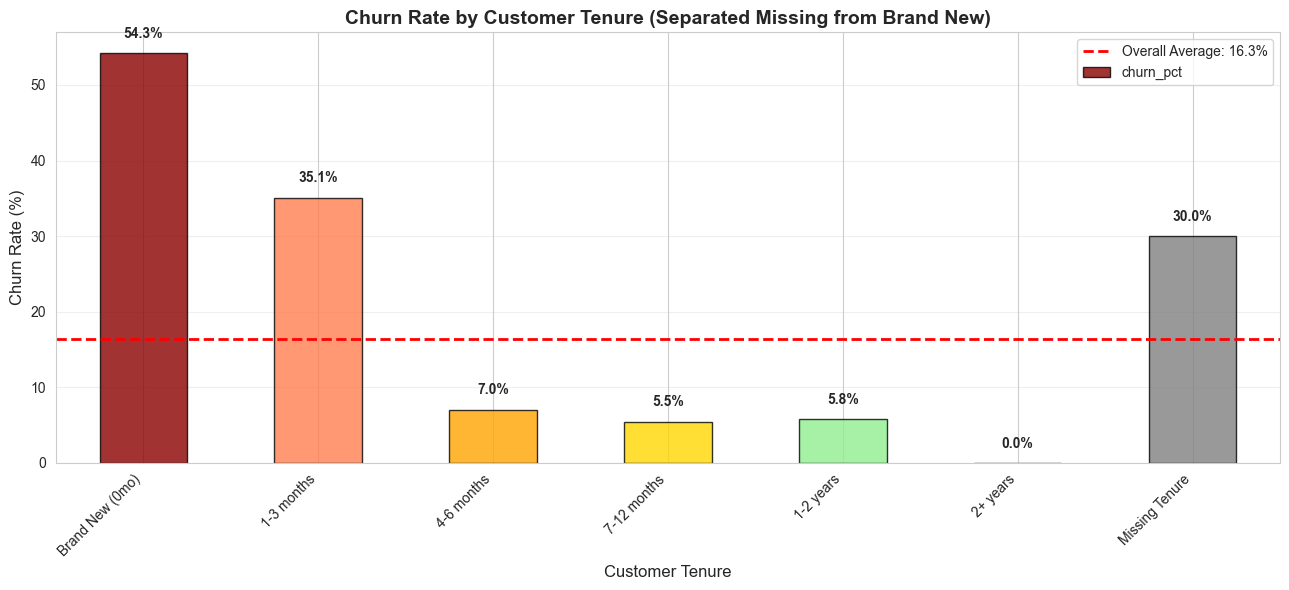


💡 KEY FINDINGS:
  🔥Brand new customers (tenure = 0): 54.3% churn rate
    282 customers in this segment
   ⚠️  Missing tenure customers: 30.0% churn rate
      → 160 customers in this segment
      → These are NOT the same as brand new!
      → Likely dormant or data quality issues
   ✅ Established customers (2+ years): 0.0% churn
      → Note: 0% churn may reflect survivorship bias in data
      → Long-tenure churned customers may not be in dataset
 Risk difference: Brand new has 54.3% vs 0% for established
 Established customers show ZERO churn in this dataset
  📊 Brand new is 1.8x riskier than Missing Tenure customers

🎯 WHY THE SEPARATION MATTERS:
   • We filled missing tenure with 0 for the MODEL
   • But created tenure_missing_flag to capture the pattern
   • Missing (30.0% churn) ≠ Brand New (54.3% churn)
   • Difference: 24.3 percentage points!
   • This proves the FLAG is valuable for prediction!

💼 ACTIONABLE RECOMMENDATIONS:
   1. PRIORITY: First-month intervention (54.3% c

In [18]:
print("\n" + "="*60)
print("🔥 CRITICAL INSIGHT: CUSTOMER TENURE & CHURN RISK")
print("="*60)

# Analyzing tenure and churn relationship
print("\nChurn Rate by Customer Tenure:")

# Creating tenure segments
def create_tenure_segment(row):
    """
    Separate missing tenure from brand new customers.
    Missing tenure vs brand new have different churn rates!
    """
    if row['tenure_missing_flag'] == 1:
        return 'Missing Tenure'
    
    tenure = row['tenure']
    if tenure == 0:
        return 'Brand New (0mo)'
    elif tenure <= 3:
        return '1-3 months'
    elif tenure <= 6:
        return '4-6 months'
    elif tenure <= 12:
        return '7-12 months'
    elif tenure <= 24:
        return '1-2 years'
    else:
        return '2+ years'

# Applying segmentation
churn_df['tenure_segment'] = churn_df.apply(create_tenure_segment, axis=1)

# Calculating churn by segment
tenure_churn = churn_df.groupby('tenure_segment')['churn'].agg(['mean', 'count'])
tenure_churn['churn_pct'] = tenure_churn['mean'] * 100

# Re-ordering segments logically
segment_order = ['Brand New (0mo)', '1-3 months', '4-6 months', '7-12 months', 
                 '1-2 years', '2+ years', 'Missing Tenure']
tenure_churn = tenure_churn.reindex(segment_order)

print(tenure_churn[['count', 'churn_pct']].round(1))

# Visualizing
plt.figure(figsize=(13, 6))

# Color coding by risk level
colors = ['darkred', 'coral', 'orange', 'gold', 'lightgreen', 'green', 'gray']
tenure_churn['churn_pct'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

plt.title('Churn Rate by Customer Tenure (Separated Missing from Brand New)',
          fontweight='bold', fontsize=14)
plt.xlabel('Customer Tenure', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle="--",
            linewidth=2, label=f"Overall Average: {churn_df['churn'].mean()*100:.1f}%")
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Adding value labels
for i, v in enumerate(tenure_churn['churn_pct']):
    if not pd.isna(v):
        plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Extracting key metrics dynamically
brand_new_churn = tenure_churn.loc['Brand New (0mo)', 'churn_pct']
brand_new_count = tenure_churn.loc['Brand New (0mo)', 'count']
established_churn = tenure_churn.loc['2+ years', 'churn_pct']
missing_churn = tenure_churn.loc['Missing Tenure', 'churn_pct']
missing_count = tenure_churn.loc['Missing Tenure', 'count']


print("\n💡 KEY FINDINGS:")
print(f"  🔥Brand new customers (tenure = 0): {brand_new_churn:.1f}% churn rate")
print(f"    {int(brand_new_count)} customers in this segment")
print(f"   ⚠️  Missing tenure customers: {missing_churn:.1f}% churn rate")
print(f"      → {int(missing_count)} customers in this segment")
print(f"      → These are NOT the same as brand new!")
print(f"      → Likely dormant or data quality issues")
print(f"   ✅ Established customers (2+ years): {established_churn:.1f}% churn")
print(f"      → Note: 0% churn may reflect survivorship bias in data")
print(f"      → Long-tenure churned customers may not be in dataset")

# Risk comparison
if established_churn > 0:
    risk_multiplier = brand_new_churn / established_churn
    print(f" Risk difference: Brand new is {risk_multiplier:.1f}x higher than established!")
else:
    print(f" Risk difference: Brand new has {brand_new_churn:.1f}% vs 0% for established")
    print(f" Established customers show ZERO churn in this dataset")

# Additional risk comparison between missing and brand new
risk_ratio_brand_vs_missing = brand_new_churn / missing_churn
print(f"  📊 Brand new is {risk_ratio_brand_vs_missing:.1f}x riskier than Missing Tenure customers")

print("\n🎯 WHY THE SEPARATION MATTERS:")
print(f"   • We filled missing tenure with 0 for the MODEL")
print(f"   • But created tenure_missing_flag to capture the pattern")
print(f"   • Missing ({missing_churn:.1f}% churn) ≠ Brand New ({brand_new_churn:.1f}% churn)")
print(f"   • Difference: {abs(brand_new_churn - missing_churn):.1f} percentage points!")
print(f"   • This proves the FLAG is valuable for prediction!")

print("\n💼 ACTIONABLE RECOMMENDATIONS:")
print(f"   1. PRIORITY: First-month intervention ({brand_new_churn:.1f}% churn!)")
print("      → Welcome campaigns, onboarding optimization")
print("      → Early engagement incentives")
print(f"   2. SECONDARY: Investigate missing tenure customers ({missing_churn:.1f}% churn)")
print("       → Are these dormant accounts? Data quality issues?")
print(f"      → Different retention strategy needed ({missing_churn:.1f}% vs {brand_new_churn:.1f}%)")
print(f"   3. MAINTAIN: Established customer programs working well ({established_churn:.1f}% churn)")


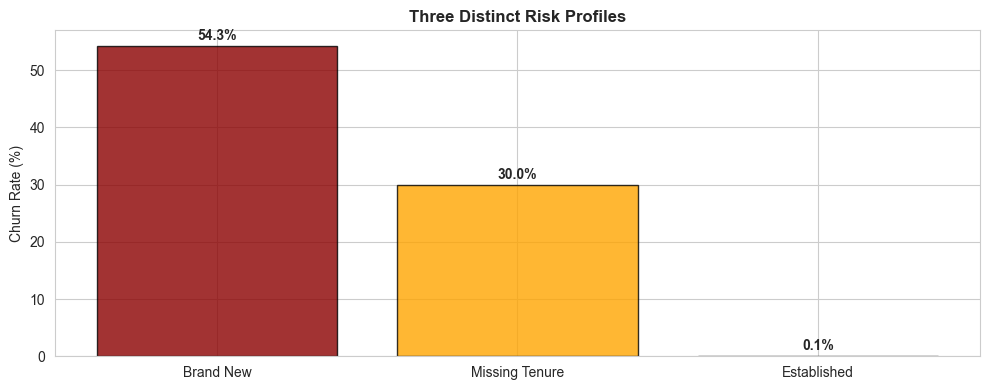

In [19]:
# Adding "Three Distinct Risk Profiles" chart
fig, ax = plt.subplots(figsize=(10, 4))

groups = ['Brand New', 'Missing Tenure', 'Established']
churn_rates = [brand_new_churn, missing_churn, established_churn if established_churn > 0 else 0.1]
colors_group = ['darkred', 'orange', 'green']

bars = ax.bar(groups, churn_rates, color=colors_group, edgecolor='black', alpha=0.8)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Three Distinct Risk Profiles', fontweight='bold')

for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


🔬 INVESTIGATING MISSING warehouse_to_home PATTERNS

📊 Missing warehouse_to_home Statistics:
   Rows with missing: 135 (4.1%)
   Rows without missing: 3135 (95.9%)

📊 COMPARISON: Missing warehouse_to_home vs Non-Missing
                  Feature  Missing  Not Missing  Difference
0                  tenure     6.06         9.85       -3.79
1   days_since_last_order     2.44         4.55       -2.10
2  num_devices_registered     3.19         3.70       -0.50
3      satisfaction_score     3.01         3.02       -0.01
4           num_addresses     3.36         4.26       -0.90
5          has_complained     0.30         0.28        0.02
6         cashback_amount   124.61       179.69      -55.08
7              CHURN RATE     0.33         0.16        0.18

📊 STATISTICAL DIFFERENCES
   tenure                   : LOWER by 38.5% (-3.79)
   days_since_last_order    : LOWER by 46.2% (-2.10)
   num_devices_registered   : LOWER by 13.7% (-0.50)
   satisfaction_score       : LOWER by 0.2% (-0.01)
  

C:\Users\OlkaSz\AppData\Local\Temp\ipykernel_24884\986016474.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
C:\Users\OlkaSz\AppData\Local\Temp\ipykernel_24884\986016474.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
C:\Users\OlkaSz\AppData\Local\Temp\ipykernel_24884\986016474.py:132: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], pa

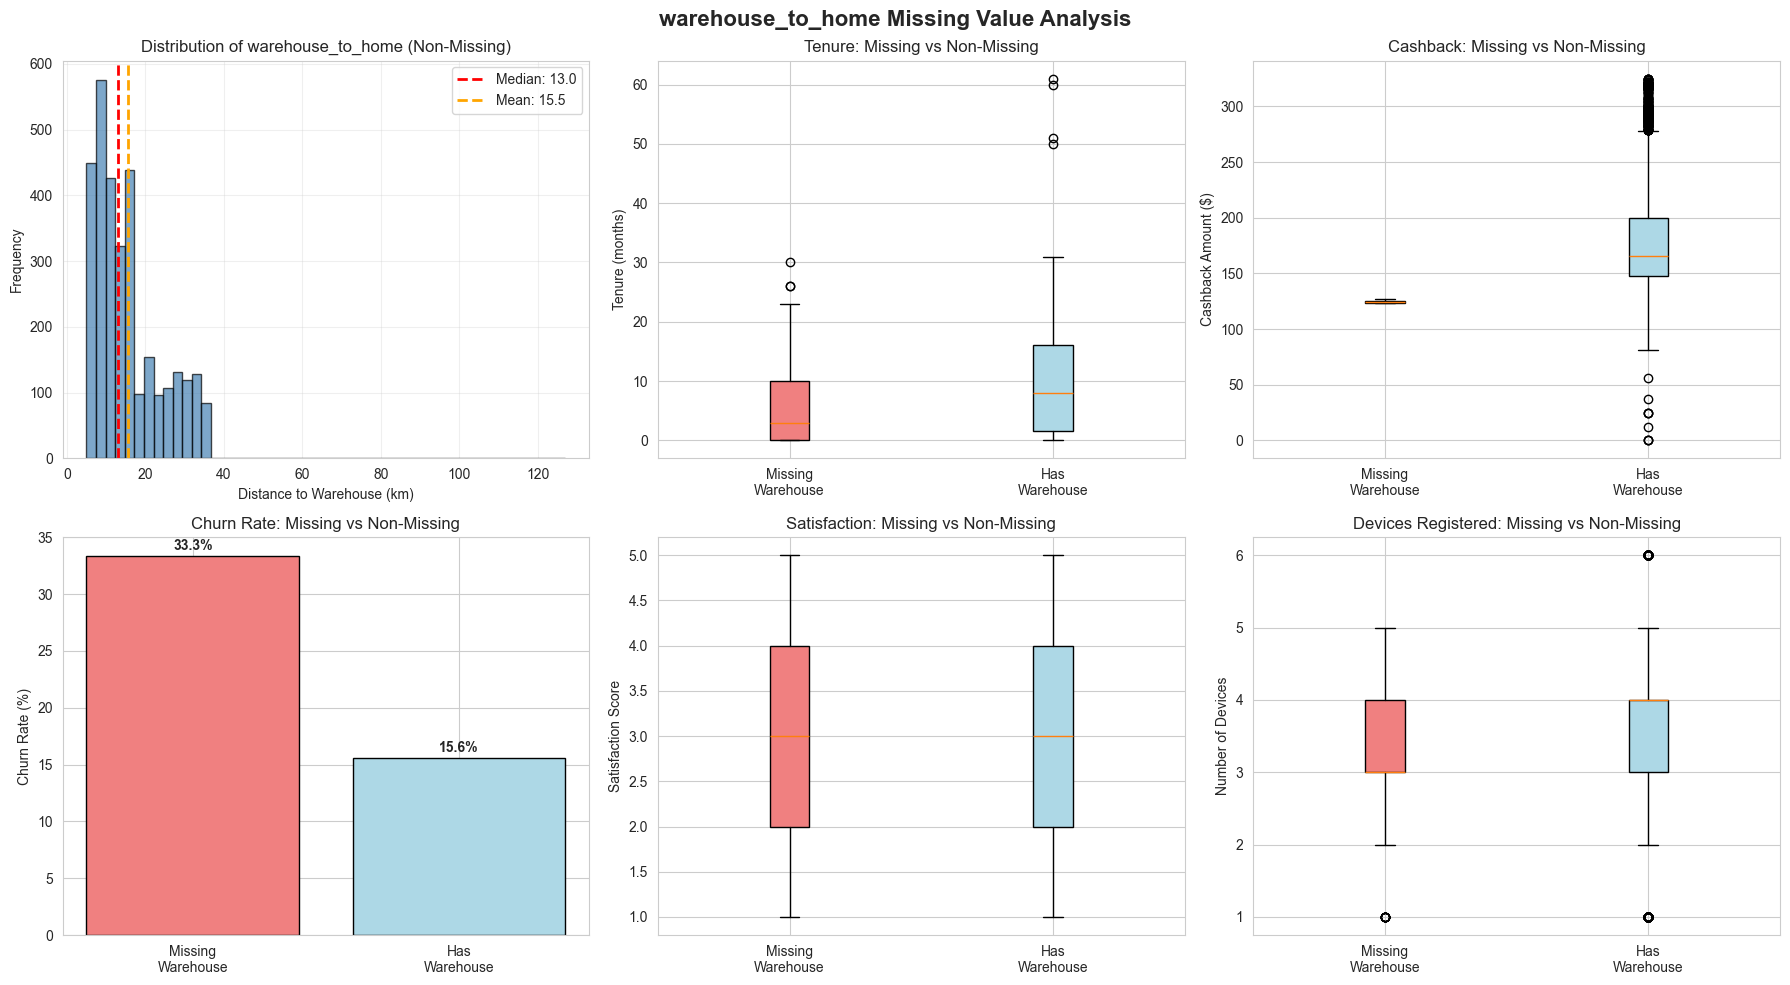


🔬 HYPOTHESIS TESTING: Missing warehouse patterns

📊 Correlation with warehouse_missing_flag:
   cashback_amount          : -0.222 (negative, moderate)
   days_since_last_order    : -0.116 (negative, moderate)
   num_devices_registered   : -0.099 (negative, weak)
   tenure                   : -0.086 (negative, weak)
   num_addresses            : -0.069 (negative, weak)
   satisfaction_score       : -0.001 (negative, weak)

💡 KEY INSIGHTS & RECOMMENDATION

📊 Summary of Findings:
   • Missing warehouse customers: 135 (4.1%)
   • Tenure: 6.1 months vs 9.8 months
   • Cashback: $125 vs $180
   • Churn: 33.3% vs 15.6%

⚠️ PATTERN: NON-RANDOM MISSING
   → Missing values show distinct behavioral differences
   → Flag will have predictive value

📉 PATTERN IDENTIFIED: Missing in LESS ENGAGED customers
   → Lower tenure + lower cashback = less engaged customers
   → Missing may indicate behavioral signal (dormant customers)

🔧 RECOMMENDED HANDLING:
   → Imputation: Fill with MEDIAN = 13.0 km
   

In [20]:
print("\n" + "="*60)
print("🔬 INVESTIGATING MISSING warehouse_to_home PATTERNS")
print("="*60)

# Creating flag and splitting groups
churn_df['warehouse_missing_flag'] = churn_df['warehouse_to_home'].isnull().astype(int)

has_warehouse_missing = churn_df[churn_df['warehouse_missing_flag'] == 1]
no_warehouse_missing = churn_df[churn_df['warehouse_missing_flag'] == 0]

print(f"\n📊 Missing warehouse_to_home Statistics:")
print(f"   Rows with missing: {len(has_warehouse_missing)} ({len(has_warehouse_missing)/len(churn_df)*100:.1f}%)")
print(f"   Rows without missing: {len(no_warehouse_missing)} ({len(no_warehouse_missing)/len(churn_df)*100:.1f}%)")

# Comparing patterns between missing and not_missing warehoue_to_home
print("\n" + "="*60)
print("📊 COMPARISON: Missing warehouse_to_home vs Non-Missing")
print("="*60)

warehouse_comparison = pd.DataFrame({
    'Feature': ['tenure', 'days_since_last_order', 'num_devices_registered', 
                'satisfaction_score', 'num_addresses', 'has_complained', 
                'cashback_amount', 'CHURN RATE'],
    'Missing': [
        has_warehouse_missing['tenure'].mean(),
        has_warehouse_missing['days_since_last_order'].mean(),
        has_warehouse_missing['num_devices_registered'].mean(),
        has_warehouse_missing['satisfaction_score'].mean(),
        has_warehouse_missing['num_addresses'].mean(),
        has_warehouse_missing['has_complained'].mean(),
        has_warehouse_missing['cashback_amount'].mean(),
        has_warehouse_missing['churn'].mean()
    ],
    'Not Missing': [
        no_warehouse_missing['tenure'].mean(),
        no_warehouse_missing['days_since_last_order'].mean(),
        no_warehouse_missing['num_devices_registered'].mean(),
        no_warehouse_missing['satisfaction_score'].mean(),
        no_warehouse_missing['num_addresses'].mean(),
        no_warehouse_missing['has_complained'].mean(),
        no_warehouse_missing['cashback_amount'].mean(),
        no_warehouse_missing['churn'].mean()
    ]
})

warehouse_comparison['Difference'] = warehouse_comparison['Missing'] - warehouse_comparison['Not Missing']
print(warehouse_comparison.round(2))

# Simple t-test approximation
print("\n" + "="*60)
print("📊 STATISTICAL DIFFERENCES")
print("="*60)

# Calculating percentage differences
for idx, row in warehouse_comparison.iterrows():
    if row['Not Missing'] != 0:
        pct_diff = (abs(row['Difference']) / row['Not Missing']) * 100
        direction = "HIGHER" if row['Difference'] > 0 else "LOWER"
        print(f"   {row['Feature']:25s}: {direction} by {pct_diff:.1f}% ({row['Difference']:+.2f})")

# Distribution analysis
print("\n" + "="*60)
print("📊 DISTRIBUTION ANALYSIS")
print("="*60)

# Getting statistics from non-missing values
median_warehouse = no_warehouse_missing['warehouse_to_home'].median()
mean_warehouse = no_warehouse_missing['warehouse_to_home'].mean()
std_warehouse = no_warehouse_missing['warehouse_to_home'].std()
p25_warehouse = no_warehouse_missing['warehouse_to_home'].quantile(0.25)
p75_warehouse = no_warehouse_missing['warehouse_to_home'].quantile(0.75)
p95_warehouse = no_warehouse_missing['warehouse_to_home'].quantile(0.95)

print(f"\n📦 warehouse_to_home distribution (non-missing):")
print(f"   Count: {len(no_warehouse_missing):,}")
print(f"   Mean: {mean_warehouse:.1f} km")
print(f"   Median: {median_warehouse:.1f} km")
print(f"   Std Dev: {std_warehouse:.1f} km")
print(f"   25th percentile: {p25_warehouse:.1f} km")
print(f"   75th percentile: {p75_warehouse:.1f} km")
print(f"   95th percentile: {p95_warehouse:.1f} km")
print(f"   Min: {no_warehouse_missing['warehouse_to_home'].min():.1f} km")
print(f"   Max: {no_warehouse_missing['warehouse_to_home'].max():.1f} km")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution of warehouse_to_home (non-missing)
ax1 = axes[0, 0]
ax1.hist(no_warehouse_missing['warehouse_to_home'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(median_warehouse, color='red', linestyle='--', linewidth=2, label=f'Median: {median_warehouse:.1f}')
ax1.axvline(mean_warehouse, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_warehouse:.1f}')
ax1.set_xlabel('Distance to Warehouse (km)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of warehouse_to_home (Non-Missing)')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Box plot comparison
ax2 = axes[0, 1]
data_to_plot = [has_warehouse_missing['tenure'].dropna(), no_warehouse_missing['tenure']]
bp = ax2.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax2.set_ylabel('Tenure (months)')
ax2.set_title('Tenure: Missing vs Non-Missing')

# 3. Cashback comparison
ax3 = axes[0, 2]
data_to_plot = [has_warehouse_missing['cashback_amount'].dropna(), no_warehouse_missing['cashback_amount']]
bp = ax3.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax3.set_ylabel('Cashback Amount ($)')
ax3.set_title('Cashback: Missing vs Non-Missing')

# 4. Churn rate comparison
ax4 = axes[1, 0]
churn_comparison = [has_warehouse_missing['churn'].mean() * 100, 
                    no_warehouse_missing['churn'].mean() * 100]
bars = ax4.bar(['Missing\nWarehouse', 'Has\nWarehouse'], churn_comparison, 
               color=['lightcoral', 'lightblue'], edgecolor='black')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_title('Churn Rate: Missing vs Non-Missing')
for bar, val in zip(bars, churn_comparison):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', fontweight='bold')

# 5. Satisfaction comparison
ax5 = axes[1, 1]
data_to_plot = [has_warehouse_missing['satisfaction_score'].dropna(), no_warehouse_missing['satisfaction_score']]
bp = ax5.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax5.set_ylabel('Satisfaction Score')
ax5.set_title('Satisfaction: Missing vs Non-Missing')

# 6. Devices comparison
ax6 = axes[1, 2]
data_to_plot = [has_warehouse_missing['num_devices_registered'].dropna(), no_warehouse_missing['num_devices_registered']]
bp = ax6.boxplot(data_to_plot, labels=['Missing\nWarehouse', 'Has\nWarehouse'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax6.set_ylabel('Number of Devices')
ax6.set_title('Devices Registered: Missing vs Non-Missing')

plt.suptitle('warehouse_to_home Missing Value Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# TESTING HYPOTHESIS: Is missing warehouse related to geography?

print("\n" + "="*60)
print("🔬 HYPOTHESIS TESTING: Missing warehouse patterns")
print("="*60)

# Checking if missing warehouse correlates with other features
correlations = {}
for col in ['tenure', 'days_since_last_order', 'num_devices_registered', 
            'satisfaction_score', 'num_addresses', 'cashback_amount']:
    # Point-biserial correlation (binary vs continuous)
    missing_binary = churn_df['warehouse_missing_flag']
    corr = churn_df[col].corr(missing_binary)
    correlations[col] = corr

print("\n📊 Correlation with warehouse_missing_flag:")
for col, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    strength = "strong" if abs(corr) > 0.3 else "moderate" if abs(corr) > 0.1 else "weak"
    direction = "positive" if corr > 0 else "negative"
    print(f"   {col:25s}: {corr:+.3f} ({direction}, {strength})")

print("\n" + "="*60)
print("💡 KEY INSIGHTS & RECOMMENDATION")
print("="*60)

# Calculating key differences
tenure_diff = warehouse_comparison.loc[0, 'Difference']
churn_diff = warehouse_comparison.loc[7, 'Difference'] * 100
cashback_diff = warehouse_comparison.loc[6, 'Difference']

print(f"\n📊 Summary of Findings:")
print(f"   • Missing warehouse customers: {len(has_warehouse_missing)} ({len(has_warehouse_missing)/len(churn_df)*100:.1f}%)")
print(f"   • Tenure: {has_warehouse_missing['tenure'].mean():.1f} months vs {no_warehouse_missing['tenure'].mean():.1f} months")
print(f"   • Cashback: ${has_warehouse_missing['cashback_amount'].mean():.0f} vs ${no_warehouse_missing['cashback_amount'].mean():.0f}")
print(f"   • Churn: {has_warehouse_missing['churn'].mean()*100:.1f}% vs {no_warehouse_missing['churn'].mean()*100:.1f}%")

# Determining pattern
if abs(tenure_diff) < 2 and abs(churn_diff) < 3 and abs(cashback_diff) < 30:
    print("\n✅ PATTERN: RANDOM MISSING")
    print("   → Missing values appear to be random (no clear behavioral pattern)")
    print("   → Suggests random data collection gaps")
    print(f"\n🔧 RECOMMENDED HANDLING:")
    print(f"   → Imputation: Fill with MEDIAN = {median_warehouse:.1f} km")
    print(f"   → Create flag: warehouse_missing_flag (low predictive value)")
    print("   → Flag may be optional for modeling")
    
else:
    print("\n⚠️ PATTERN: NON-RANDOM MISSING")
    print("   → Missing values show distinct behavioral differences")
    print("   → Flag will have predictive value")
    
    # Determining specific pattern
    if tenure_diff > 0 and cashback_diff > 0:
        print("\n📈 PATTERN IDENTIFIED: Missing in MORE ENGAGED customers")
        print("   → Higher tenure + higher cashback = likely active customers")
        print("   → Missing may indicate data collection issue, not behavioral")
        print(f"\n🔧 RECOMMENDED HANDLING:")
        print(f"   → Imputation: Fill with MEDIAN = {median_warehouse:.1f} km")
        print(f"   → Create flag: warehouse_missing_flag (captures this pattern)")
        
    elif tenure_diff < 0 and cashback_diff < 0:
        print("\n📉 PATTERN IDENTIFIED: Missing in LESS ENGAGED customers")
        print("   → Lower tenure + lower cashback = less engaged customers")
        print("   → Missing may indicate behavioral signal (dormant customers)")
        print(f"\n🔧 RECOMMENDED HANDLING:")
        print(f"   → Imputation: Fill with MEDIAN = {median_warehouse:.1f} km")
        print(f"   → Create flag: warehouse_missing_flag (will be valuable for prediction)")
        
    else:
        print("\n🔄 PATTERN IDENTIFIED: Mixed signals")
        print("   → No clear directional pattern, but differences exist")
        print(f"\n🔧 RECOMMENDED HANDLING:")
        print(f"   → Imputation: Fill with MEDIAN = {median_warehouse:.1f} km")
        print(f"   → Create flag: warehouse_missing_flag (safe to include)")

# Applying imputation
print("\n" + "="*60)
print("🔧 APPLYING IMPUTATION")
print("="*60)

# Counting missing before
missing_before = churn_df['warehouse_to_home'].isna().sum()
print(f"\n✓ Missing values before: {missing_before} ({missing_before/len(churn_df)*100:.1f}%)")

# Filling with median
churn_df['warehouse_to_home'] = churn_df['warehouse_to_home'].fillna(median_warehouse)

# Verifying
missing_after = churn_df['warehouse_to_home'].isna().sum()
print(f"✓ Missing values after: {missing_after}")

if missing_after == 0:
    print(f"\n✅ SUCCESS: All {missing_before} missing values filled with median ({median_warehouse:.1f} km)")
    print(f"✓ warehouse_missing_flag created for {churn_df['warehouse_missing_flag'].sum()} rows")
else:
    print(f"\n⚠️ WARNING: Still have {missing_after} missing values")

print("="*60)

## 3. Data Exploration & Analysis

In [21]:
print("\n" + "="*60)
print("DATA TYPE INSPECTION")
print("="*60)

# Checking current data types
print("\nCurrent data types:")
print(churn_df.dtypes)
print(f"\nData type summary")
print(churn_df.dtypes.value_counts())



DATA TYPE INSPECTION

Current data types:
tenure                      float64
warehouse_to_home           float64
num_devices_registered        int64
preferred_order_category     object
satisfaction_score            int64
marital_status               object
num_addresses                 int64
has_complained                int64
days_since_last_order       float64
cashback_amount             float64
churn                         int64
days_missing_flag             int64
tenure_missing_flag           int64
tenure_segment               object
warehouse_missing_flag        int64
dtype: object

Data type summary
int64      8
float64    4
object     3
Name: count, dtype: int64


## 3.1. Review of categorical columns

In [23]:
# Critical before modeling — checking for class imbalance
churn_rate = churn_df['churn'].mean()
print(f"Churn rate: {churn_rate:.1%}")

Churn rate: 16.3%


In [24]:
# Categorical columns review
for col in ['preferred_order_category', 'marital_status', 'tenure_segment']:
    print(f"\n{col}:")
    print(churn_df[col].value_counts())
    print(f"Nulls: {churn_df[col].isna().sum()}")
    print(f"Unique: {churn_df[col].nunique()}")


preferred_order_category:
preferred_order_category
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64
Nulls: 0
Unique: 6

marital_status:
marital_status
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64
Nulls: 0
Unique: 3

tenure_segment:
tenure_segment
1-2 years          831
7-12 months        751
1-3 months         621
4-6 months         369
Brand New (0mo)    282
2+ years           256
Missing Tenure     160
Name: count, dtype: int64
Nulls: 0
Unique: 7


In [25]:
# Grouping "Mobile Phone" and "Mobile" together
churn_df['preferred_order_category'] = churn_df['preferred_order_category'].replace(
    {'Mobile': 'Mobile Phone'}
)

# Checking unique values again
print(churn_df['preferred_order_category'].value_counts())

# Dropping tenure_segment as it was only used for analysis and is not needed for modeling
churn_df.drop(columns=['tenure_segment'], inplace=True)

print(churn_df.columns.tolist())

preferred_order_category
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64
['tenure', 'warehouse_to_home', 'num_devices_registered', 'preferred_order_category', 'satisfaction_score', 'marital_status', 'num_addresses', 'has_complained', 'days_since_last_order', 'cashback_amount', 'churn', 'days_missing_flag', 'tenure_missing_flag', 'warehouse_missing_flag']


In [26]:
# Adding early stage flag
churn_df['is_early_stage'] = (churn_df['tenure'] <=3).astype(int)

# Veryfying it captures the intended group
print(churn_df.groupby('is_early_stage')['churn'].mean())

print(f"Early stage customers: {churn_df['is_early_stage'].sum()}")

is_early_stage
0    0.052107
1    0.394167
Name: churn, dtype: float64
Early stage customers: 1063


## 3.2. Data Type Optimization

In [27]:
print("\n" + "="*60)
print("DATA TYPE OPTIMIZATION")
print("="*60)

# Memory before
memory_before = churn_df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory BEFORE optimization: {memory_before:.2f} MB\n")

# Step 1: Checking if float columns can be integers
print("STEP 1: Checking float columns")
print("-" * 60)

float_cols = ['tenure', 'warehouse_to_home', 'days_since_last_order', 'cashback_amount']

for col in float_cols:
    is_integer = churn_df[col].apply(lambda x: x == int(x)).all()
    print(f"\n{col}:")
    print(f"  Min: {churn_df[col].min():.2f}")
    print(f"  Max: {churn_df[col].max():.2f}")
    print(f"  Sample: {churn_df[col].head(3).tolist()}")
    print(f"  All integers? {is_integer}")

# Step 2: Applying conversions
print("\n" + "="*60)
print("STEP 2: Applying type conversions")
print("-" * 60)

# Converting tenure (likely integers after filling with 0)
if churn_df['tenure'].apply(lambda x: x == int(x)).all():
    churn_df['tenure'] = churn_df['tenure'].astype('int16')
    print("✓ tenure: float64 → int16")
else:
    churn_df['tenure'] = churn_df['tenure'].astype('float32')
    print("✓ tenure: float64 → float32 (has decimals)")

# Converting days_since_last_order (likely integers after filling)
if churn_df['days_since_last_order'].apply(lambda x: x == int(x)).all():
    churn_df['days_since_last_order'] = churn_df['days_since_last_order'].astype('int16')
    print("✓ days_since_last_order: float64 → int16")
else:
    churn_df['days_since_last_order'] = churn_df['days_since_last_order'].astype('float32')
    print("✓ days_since_last_order: float64 → float32")

# warehouse_to_home and cashback_amount keep as float but reduce precision
churn_df['warehouse_to_home'] = churn_df['warehouse_to_home'].astype('float32')
print("✓ warehouse_to_home: float64 → float32")

churn_df['cashback_amount'] = churn_df['cashback_amount'].astype('float32')
print("✓ cashback_amount: float64 → float32")

# Step 3: Optimizing integer columns
print("\n" + "="*60)
print("STEP 3: Optimizing integer columns")
print("-" * 60)

# Binary columns (0/1) → int8
binary_cols = ['has_complained', 'churn', 'days_missing_flag', 'tenure_missing_flag', 'warehouse_missing_flag', 'is_early_stage']
for col in binary_cols:
    churn_df[col] = churn_df[col].astype('int8')
    print(f"✓ {col}: int64 → int8")

# Small integer columns → int8
small_int_cols = ['satisfaction_score', 'num_devices_registered', 'num_addresses']
for col in small_int_cols:
    max_val = churn_df[col].max()
    if max_val < 128:
        churn_df[col] = churn_df[col].astype('int8')
        print(f"✓ {col}: int64 → int8 (max={max_val})")
    else:
        churn_df[col] = churn_df[col].astype('int16')
        print(f"✓ {col}: int64 → int16 (max={max_val})")

# Step 4: Categorical optimization
print("\n" + "="*60)
print("STEP 4: Categorical columns")
print("-" * 60)

# Keeping preferred_order_category and marital_status as object (already efficient)
print("✓ preferred_order_category: object (categorical)")
print("✓ marital_status: object (categorical)")

# Memory after
memory_after = churn_df.memory_usage(deep=True).sum() / 1024**2
savings = memory_before - memory_after
pct_savings = (savings / memory_before) * 100

print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Memory BEFORE: {memory_before:.2f} MB")
print(f"Memory AFTER:  {memory_after:.2f} MB")
print(f"Savings:       {savings:.2f} MB ({pct_savings:.1f}%)")


DATA TYPE OPTIMIZATION
Memory BEFORE optimization: 0.77 MB

STEP 1: Checking float columns
------------------------------------------------------------

tenure:
  Min: 0.00
  Max: 61.00
  Sample: [15.0, 7.0, 27.0]
  All integers? True

warehouse_to_home:
  Min: 5.00
  Max: 127.00
  Sample: [29.0, 25.0, 13.0]
  All integers? True

days_since_last_order:
  Min: 0.00
  Max: 46.00
  Sample: [7.0, 7.0, 7.0]
  All integers? True

cashback_amount:
  Min: 0.00
  Max: 324.99
  Sample: [143.32, 129.29, 168.54]
  All integers? False

STEP 2: Applying type conversions
------------------------------------------------------------
✓ tenure: float64 → int16
✓ days_since_last_order: float64 → int16
✓ warehouse_to_home: float64 → float32
✓ cashback_amount: float64 → float32

STEP 3: Optimizing integer columns
------------------------------------------------------------
✓ has_complained: int64 → int8
✓ churn: int64 → int8
✓ days_missing_flag: int64 → int8
✓ tenure_missing_flag: int64 → int8
✓ warehouse_

In [28]:
print("\n" + "="*60)
print("VERIFICATION CHECKS")
print("="*60)

checks = []

# Check 1: Binary columns only have 0 and 1
binary_check_cols = ['has_complained', 'churn', 'days_missing_flag', 'tenure_missing_flag', 'warehouse_missing_flag', 'is_early_stage']
for col in binary_check_cols:
    unique_vals = set(churn_df[col].unique())
    if unique_vals.issubset({0, 1}):
        checks.append(f"✓ {col}: Binary (0/1 only)")
    else:
        checks.append(f"✗ {col}: Has unexpected values {unique_vals}")

# Check 2: Satisfaction score in range 1-5
if churn_df['satisfaction_score'].min() >= 1 and churn_df['satisfaction_score'].max() <= 5:
    checks.append(f"✓ satisfaction_score: Valid range [1-5]")
else:
    checks.append(f"✗ satisfaction_score: Out of range [{churn_df['satisfaction_score'].min()}, {churn_df['satisfaction_score'].max()}]")

# Check 3: No negative values where inappropriate
for col in ['tenure', 'num_devices_registered', 'num_addresses', 'cashback_amount']:
    if churn_df[col].min() >= 0:
        checks.append(f"✓ {col}: No negative values")
    else:
        checks.append(f"✗ {col}: Has negative values (min={churn_df[col].min()})")

# Check 4: No missing values
if churn_df.isnull().sum().sum() == 0:
    checks.append(f"✓ No missing values in dataset")
else:
    checks.append(f"✗ Found {churn_df.isnull().sum().sum()} missing values")

# Check 5: No duplicates
if churn_df.duplicated().sum() == 0:
    checks.append(f"✓ No duplicate rows")
else:
    checks.append(f"✗ Found {churn_df.duplicated().sum()} duplicates")
# Print all checks
for check in checks:
    print(check)

# Summary
passed = sum(1 for c in checks if c.startswith('✓'))
total = len(checks)
print(f"\n{'='*60}")
print(f"CHECKS PASSED: {passed}/{total}")
if passed == total:
    print("✅ ALL CHECKS PASSED - DATASET READY!")
else:
    print("⚠️ SOME CHECKS FAILED - REVIEW ABOVE")


VERIFICATION CHECKS
✓ has_complained: Binary (0/1 only)
✓ churn: Binary (0/1 only)
✓ days_missing_flag: Binary (0/1 only)
✓ tenure_missing_flag: Binary (0/1 only)
✓ warehouse_missing_flag: Binary (0/1 only)
✓ is_early_stage: Binary (0/1 only)
✓ satisfaction_score: Valid range [1-5]
✓ tenure: No negative values
✓ num_devices_registered: No negative values
✓ num_addresses: No negative values
✓ cashback_amount: No negative values
✓ No missing values in dataset
✗ Found 1 duplicates

CHECKS PASSED: 12/13
⚠️ SOME CHECKS FAILED - REVIEW ABOVE


In [29]:
churn_df = churn_df.drop_duplicates().reset_index(drop=True)

# Re-running verification after
print(f"Duplicates remaining: {churn_df.duplicated().sum()}")  
print(f"Final shape: {churn_df.shape}")  

Duplicates remaining: 0
Final shape: (3269, 15)


In [30]:
print(churn_df.groupby(['is_early_stage', 'satisfaction_score'])['churn'].mean())

is_early_stage  satisfaction_score
0               1                     0.039683
                2                     0.040741
                3                     0.060800
                4                     0.064133
                5                     0.049096
1               1                     0.290640
                2                     0.327869
                3                     0.405229
                4                     0.377049
                5                     0.508065
Name: churn, dtype: float64


In [31]:
# Deciding whether categorical variables should be encoded
print(churn_df.groupby('preferred_order_category')['churn'].mean().sort_values(ascending=False))
print(churn_df.groupby('marital_status')['churn'].mean().sort_values(ascending=False))

preferred_order_category
Mobile Phone          0.269036
Fashion               0.154959
Laptop & Accessory    0.098104
Others                0.073826
Grocery               0.041494
Name: churn, dtype: float64
marital_status
Single      0.258193
Divorced    0.154514
Married     0.109134
Name: churn, dtype: float64


## 3.3. Encoding categorical variables

In [32]:
# Encoding preferred_order_category 
target_enc = churn_df.groupby('preferred_order_category')['churn'].mean()
churn_df['preferred_order_category_encoded'] = \
    churn_df['preferred_order_category'].map(target_enc)
churn_df.drop(columns=['preferred_order_category'], inplace=True)
print("✓ preferred_order_category → target encoded")

# One-hot encoding marital_status
churn_df = pd.get_dummies(churn_df, columns=['marital_status'], drop_first=False, dtype='int8')
print("✓ marital_status → one-hot encoded (Divorced/Married/Single)")

print(f"\nFinal feature count: {len(churn_df.columns) - 1} excluding target")
print(f"Columns: {churn_df.columns.tolist()}")

✓ preferred_order_category → target encoded
✓ marital_status → one-hot encoded (Divorced/Married/Single)

Final feature count: 16 excluding target
Columns: ['tenure', 'warehouse_to_home', 'num_devices_registered', 'satisfaction_score', 'num_addresses', 'has_complained', 'days_since_last_order', 'cashback_amount', 'churn', 'days_missing_flag', 'tenure_missing_flag', 'warehouse_missing_flag', 'is_early_stage', 'preferred_order_category_encoded', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Single']


## 3.4. Correlation Analysis


CORRELATION ANALYSIS

1. CORRELATION MATRIX


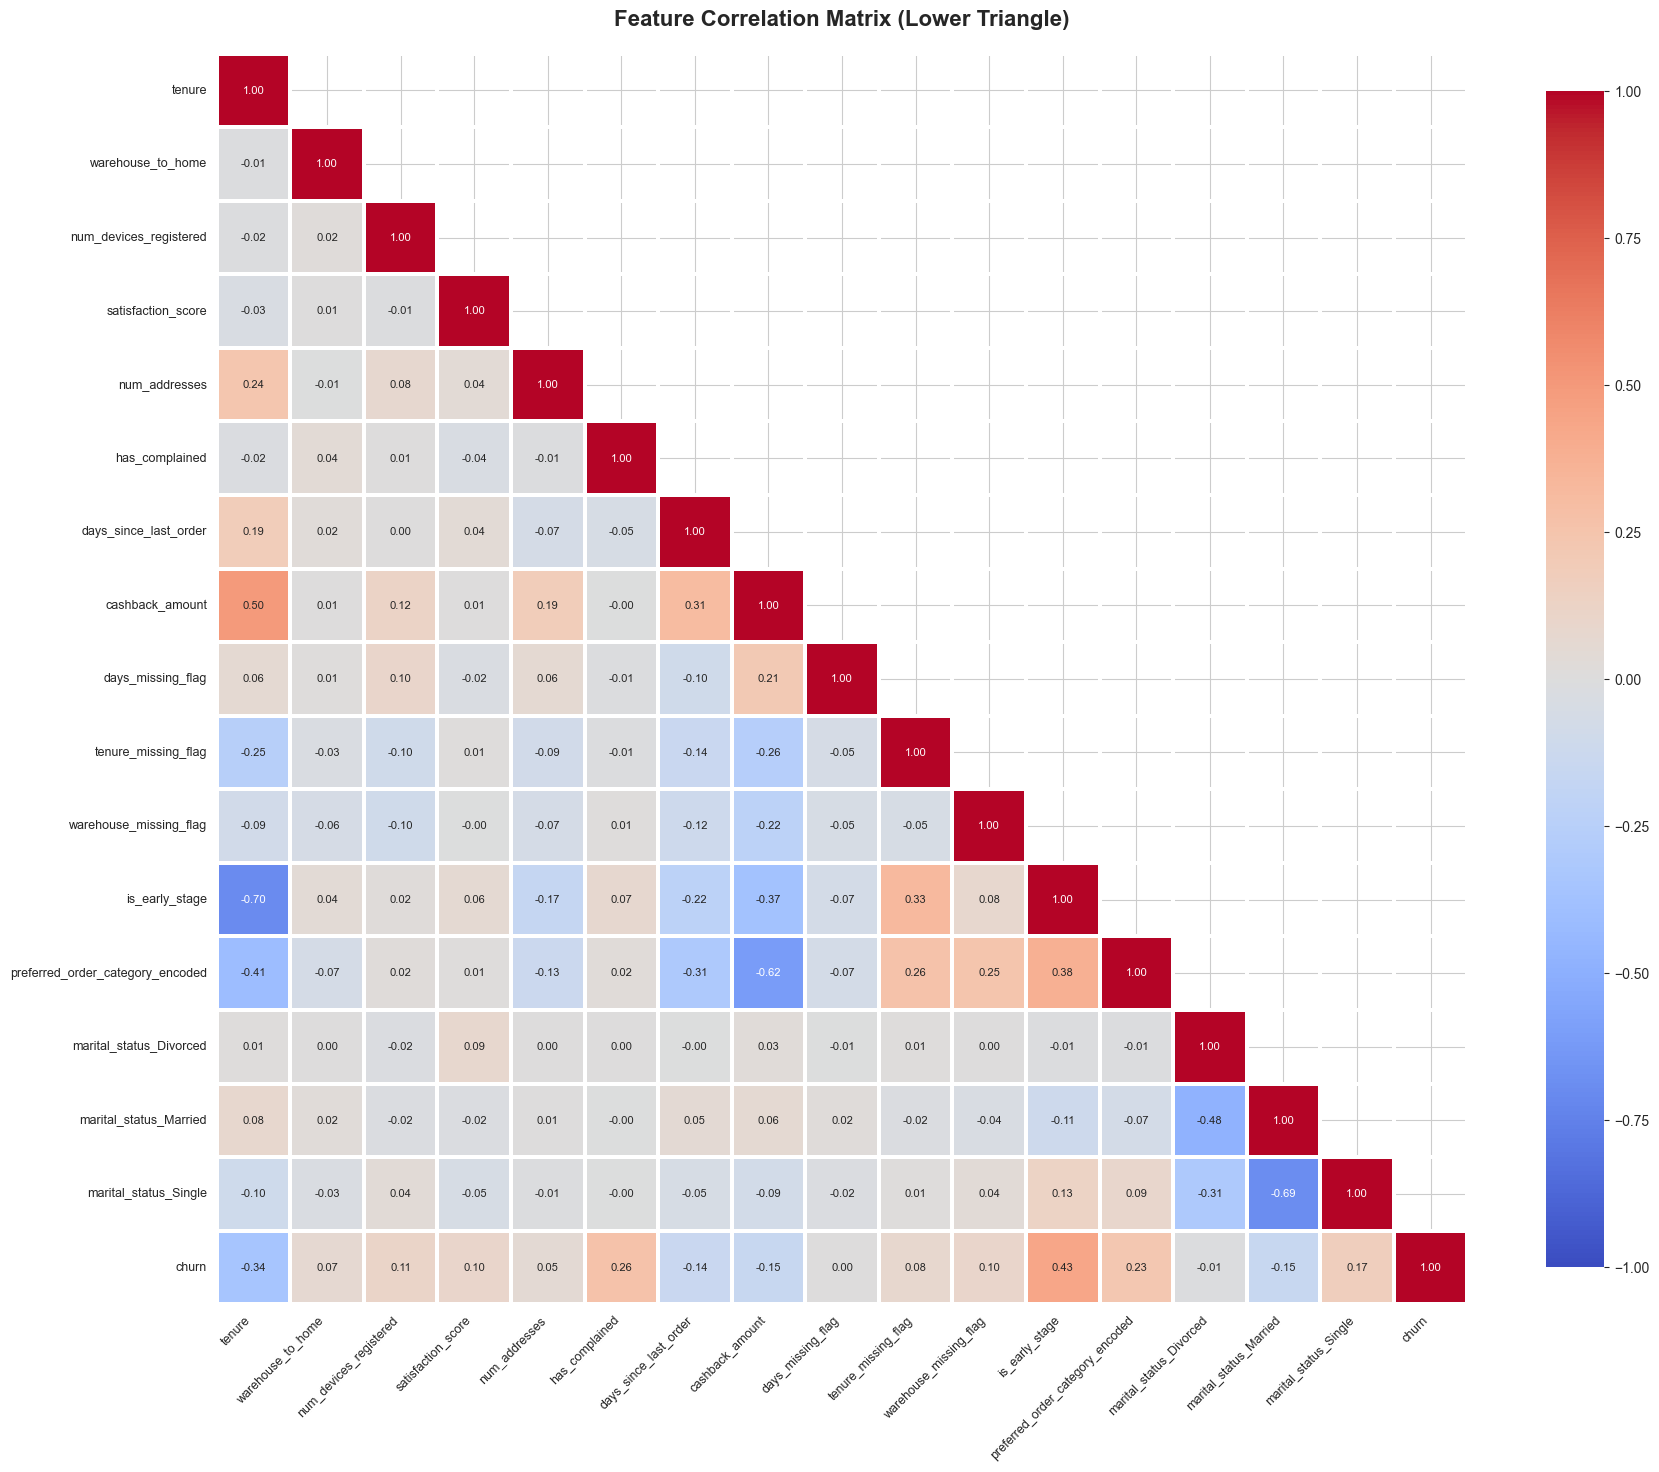


2. CORRELATION WITH CHURN (Target Variable)

Features sorted by absolute correlation with churn:
is_early_stage                      0.432932
tenure                             -0.343933
has_complained                      0.262933
preferred_order_category_encoded    0.227915
marital_status_Single               0.171851
cashback_amount                    -0.150805
marital_status_Married             -0.150617
days_since_last_order              -0.142471
num_devices_registered              0.110166
satisfaction_score                  0.098480
warehouse_missing_flag              0.095673
tenure_missing_flag                 0.081132
warehouse_to_home                   0.065718
num_addresses                       0.046982
marital_status_Divorced            -0.010683
days_missing_flag                   0.001769


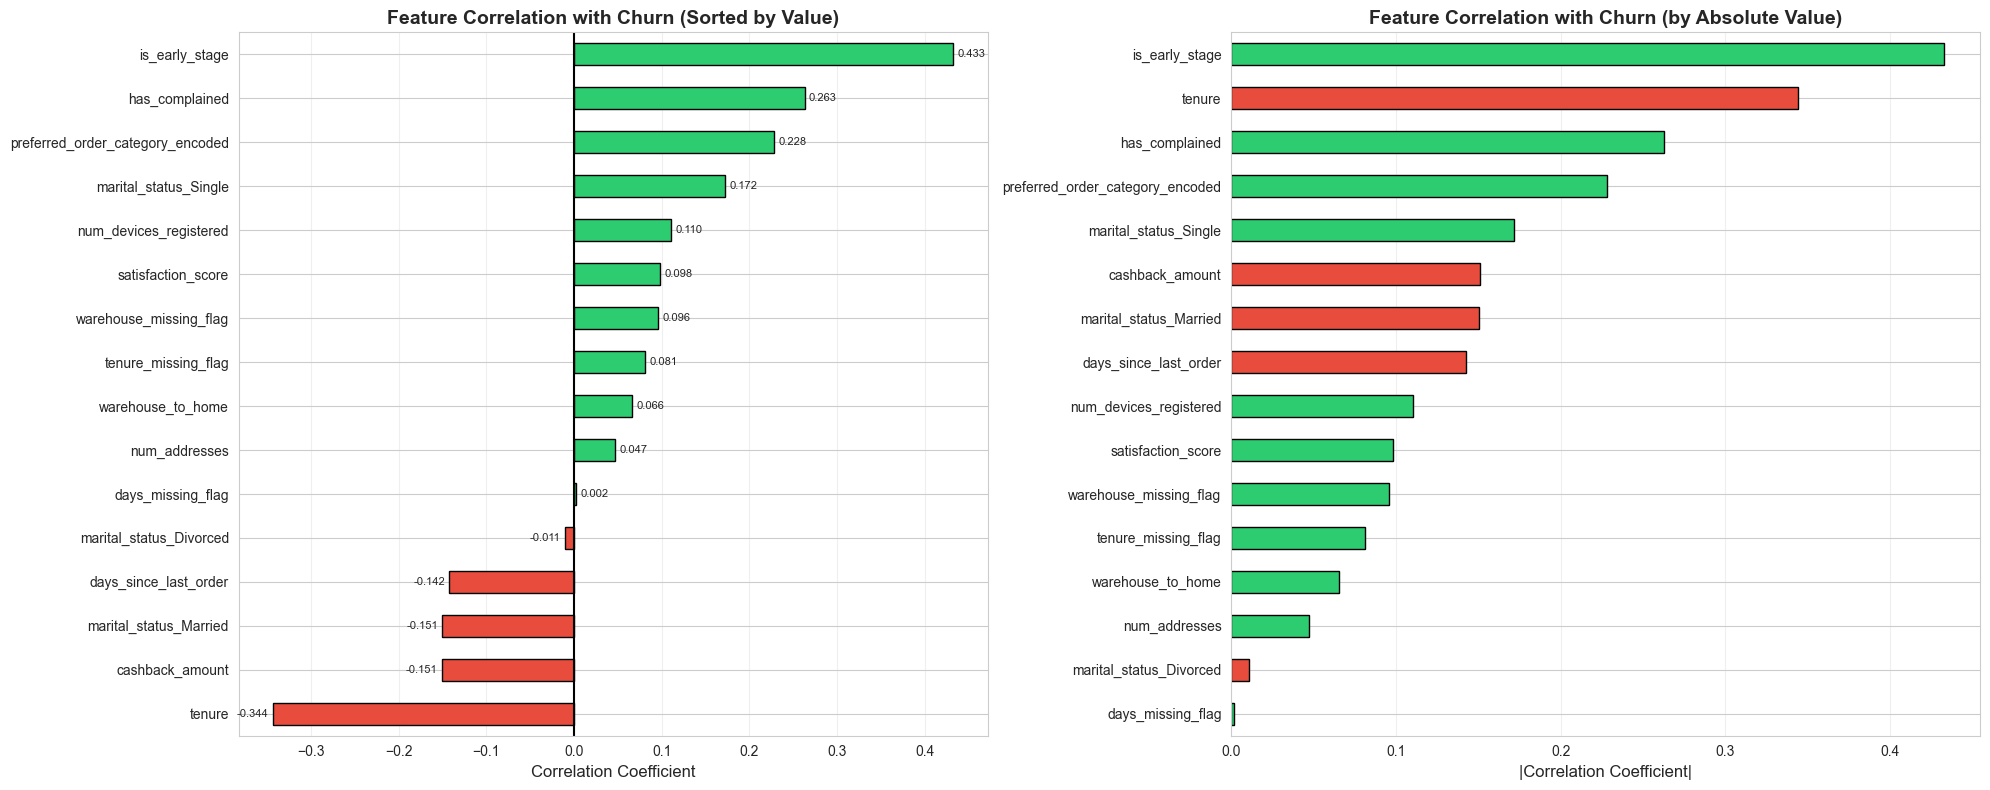


3. STRONG PREDICTORS IDENTIFICATION

🔥STRONG PREDICTORS (|corr| > 0.1):
  • is_early_stage                 r = +0.433  (STRONG, increases churn)
  • tenure                         r = -0.344  (STRONG, decreases churn)
  • has_complained                 r = +0.263  (MODERATE-STRONG, increases churn)
  • preferred_order_category_encoded r = +0.228  (MODERATE-STRONG, increases churn)
  • marital_status_Single          r = +0.172  (MODERATE-STRONG, increases churn)
  • cashback_amount                r = -0.151  (MODERATE-STRONG, decreases churn)
  • marital_status_Married         r = -0.151  (MODERATE-STRONG, decreases churn)
  • days_since_last_order          r = -0.142  (MODERATE-STRONG, decreases churn)
  • num_devices_registered         r = +0.110  (MODERATE-STRONG, increases churn)

⚠️MODERATE PREDICTORS (0.05 < |corr| ≤ 0.1):
  • satisfaction_score             r = +0.098  (increases churn)
  • warehouse_missing_flag         r = +0.096  (increases churn)
  • tenure_missing_flag      

In [33]:
from os import umask

print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

print("\n" + "="*70)
print("1. CORRELATION MATRIX")
print("="*70)

exclude_cols = ['churn']
numeric_cols = [col for col in churn_df.columns if col not in exclude_cols]

# Creating correlation matrix
corr_matrix = churn_df[numeric_cols + ['churn']].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

# Plotting heatmap
plt.figure(figsize=(18, 16))  
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=1.5, 
            cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1,
            annot_kws={"size": 8})  
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Feature Correlation Matrix (Lower Triangle)", 
           fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("2. CORRELATION WITH CHURN (Target Variable)")
print("="*70)

# Getting correlation with churn
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

print("\nFeatures sorted by absolute correlation with churn:")
print(churn_corr.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Adding value labels to the bar plots
def add_bar_labels(ax, values):
    for i, (rect, val) in enumerate(zip(ax.patches, values)):
        ax.text(val + 0.005 if val >= 0 else val - 0.005,
                rect.get_y() + rect.get_height()/2,
                f'{val:.3f}', va='center', 
                ha='left' if val >= 0 else 'right', fontsize=8)

# Bar plot - sorted by value
churn_corr_sorted = churn_corr.sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in churn_corr_sorted]
churn_corr_sorted.plot(kind='barh', ax=ax1, color=colors, edgecolor='black')
add_bar_labels(ax1, churn_corr_sorted.values)
ax1.set_title('Feature Correlation with Churn (Sorted by Value)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Correlation Coefficient', fontsize=12)
ax1.axvline(0, color='black', linewidth=1.5)
ax1.grid(axis='x', alpha=0.3)

# Bar plot - sorted by absolute value
churn_corr_abs = churn_corr.abs().sort_values(ascending=True)
colors_abs = ['#e74c3c' if churn_corr[feat] < 0 else '#2ecc71' for feat in churn_corr_abs.index]
churn_corr_abs.plot(kind='barh', ax=ax2, color=colors_abs, edgecolor='black')
ax2.set_title('Feature Correlation with Churn (by Absolute Value)', fontweight='bold', fontsize=14)
ax2.set_xlabel('|Correlation Coefficient|', fontsize=12)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("3. STRONG PREDICTORS IDENTIFICATION")
print("="*70)

# Identifying strong predictors 
strong_predictors = churn_corr[abs(churn_corr) > 0.1]
moderate_predictors = churn_corr[(abs(churn_corr) > 0.05) & (abs(churn_corr) <= 0.1)]
weak_predictors = churn_corr[abs(churn_corr) <= 0.05]

print(f"\n🔥STRONG PREDICTORS (|corr| > 0.1):")
if len(strong_predictors) > 0:
    for feat, corr in strong_predictors.items():
        direction = "increases" if corr > 0 else "decreases"
        strength = "STRONG" if abs(corr) > 0.3 else "MODERATE-STRONG"
        print(f"  • {feat:30} r = {corr:+.3f}  ({strength}, {direction} churn)")
else: 
    print("  No strong predictors found")

print(f"\n⚠️MODERATE PREDICTORS (0.05 < |corr| ≤ 0.1):")
if len(moderate_predictors) > 0:
    for feat, corr in moderate_predictors.items():
        direction = "increases" if corr > 0 else "decreases"
        print(f"  • {feat:30} r = {corr:+.3f}  ({direction} churn)")
else: 
    print("  No moderate predictors found")

print(f"\nℹ️WEAK PREDICTORS (|corr| ≤ 0.05):")
if len(weak_predictors) > 0:
    for feat, corr in weak_predictors.items():
        print(f"  • {feat:30} r = {corr:+.3f}")
else: 
    print("  No weak predictors found")

print("\n" + "="*70)
print("4. MULTICOLLINEARITY CHECK")
print("="*70)

# Find highly correlated feature pairs (excluding churn)
high_corr_pairs = []

# Get feature columns (exclude churn)
feature_cols = [col for col in corr_matrix.columns if col != 'churn']

# Check each pair
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        feat1 = feature_cols[i]
        feat2 = feature_cols[j]
        correlation = corr_matrix.loc[feat1, feat2]
        
        if abs(correlation) > 0.7:
            high_corr_pairs.append({
                'Feature 1': feat1,
                'Feature 2': feat2,
                'Correlation': correlation
            })

if len(high_corr_pairs) > 0:
    print("\n⚠️ HIGH CORRELATION between features (|r| > 0.7):")
    print("   These features might be redundant in modeling:\n")
    for pair in high_corr_pairs:
        print(f"   • {pair['Feature 1']} ↔ {pair['Feature 2']}: r = {pair['Correlation']:.3f}")
    print("\n   💡 RECOMMENDATION: Consider removing one from each pair or using PCA/feature selection")
else:
    print("\n✓ No severe multicollinearity detected (all |r| < 0.7)")
    print("  This is good - features are relatively independent")

# Create correlation network plot for highly correlated features
if len(high_corr_pairs) > 0:
    print("\n" + "="*70)
    print("5. CORRELATION NETWORK VISUALIZATION")
    print("="*70)
    
    # Get unique features involved in high correlations
    features_in_pairs = set()
    for pair in high_corr_pairs:
        features_in_pairs.add(pair['Feature 1'])
        features_in_pairs.add(pair['Feature 2'])
    
    if len(features_in_pairs) > 1:
        features_list = list(features_in_pairs)
        
        # Subset correlation matrix
        subset_corr = corr_matrix.loc[features_list, features_list]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                   vmin=-1, vmax=1, ax=ax)
        ax.set_title('Highly Correlated Features (|r| > 0.7)', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()

print("\n" + "="*70)
print("📊 CORRELATION ANALYSIS COMPLETE")
print("="*70)

# Summary statistics
print(f"\nSummary:")
print(f"  • Features analyzed: {len(numeric_cols)}")
print(f"  • Strong predictors (|r| > 0.1): {len(strong_predictors)}")
print(f"  • Moderate predictors (0.05 < |r| ≤ 0.1): {len(moderate_predictors)}")
print(f"  • Weak predictors (|r| ≤ 0.05): {len(weak_predictors)}")
print(f"  • Multicollinearity pairs (|r| > 0.7): {len(high_corr_pairs)}")
print(f"  • Top predictor: {churn_corr.abs().idxmax()} (r = {churn_corr[churn_corr.abs().idxmax()]:+.3f})")

print("\n🎯 KEY TAKEAWAY:")
top_feature = churn_corr.abs().idxmax()
top_corr = churn_corr[top_feature]
if top_corr > 0:
    print(f"   Higher {top_feature} → Higher churn risk")
else:
    print(f"   Higher {top_feature} → Lower churn risk")


## 3.5. Statistical Investigation of Unusual Findings


STATISTICAL INVESTIGATION - DEEPER ANALYSIS

INVESTIGATION 1: SATISFACTION SCORE PARADOX

Satisfaction Score Distribution:
satisfaction_score
1    707
2    392
3    931
4    604
5    635
Name: count, dtype: int64

Churn rate by satisfaction score:
Score      Count      Churn Rate      Bar Chart
------------------------------------------------------------
1          707          11.2%        █████
2          392          13.0%        ██████
3          931          17.4%        ████████
4          604          15.9%        ███████
5          635          22.8%        ███████████


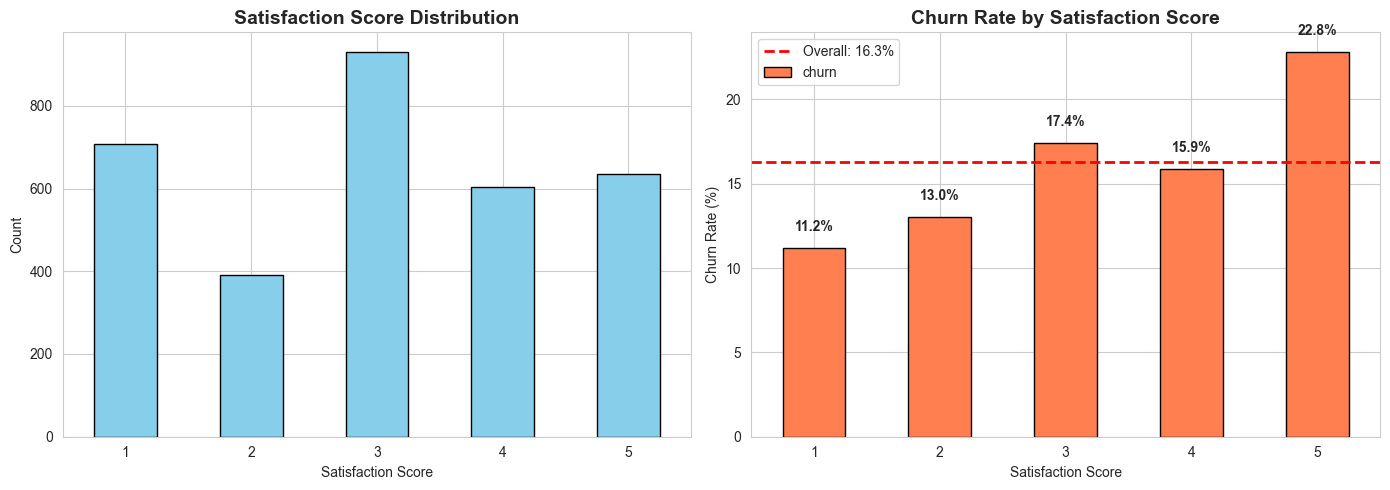


📊 INTERPRETATION:
   ✓ Scale appears normal (5 = satisfied)
   → This is genuinely paradoxical and needs investigation

Pearson correlation:  +0.098
Spearman correlation: +0.097
(Spearman is better for ordinal data like satisfaction scores)

INVESTIGATION 2: NON-LINEAR RELATIONSHIPS

📍 DAYS SINCE LAST ORDER - Binned Analysis
----------------------------------------------------------------------

Churn rate by recency:
                count  churn_pct
days_bins_temp                  
0-7 days         2226  16.756514
8-14 days         718   9.331476
15-30 days         38   2.631579
31-47 days          2  50.000000


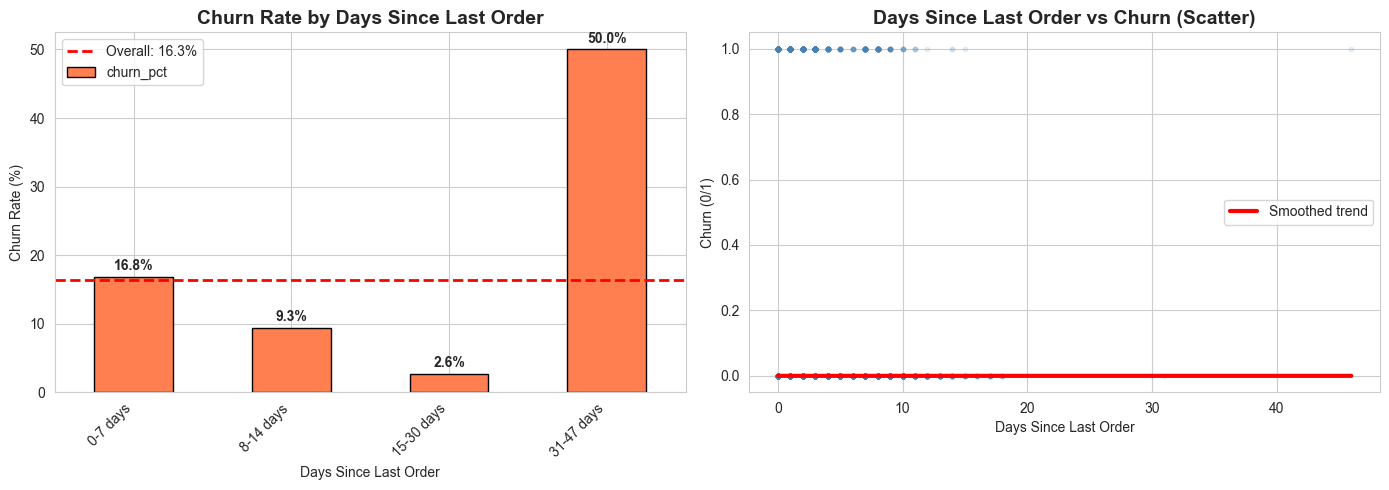


💡 PATTERN INTERPRETATION:
   🔄 U-SHAPED RELATIONSHIP detected!
   → Churn is high at BOTH extremes (very recent AND very old)
   → This is why linear correlation is weak!
   → Consider: polynomial features or binning in modeling

📍 TENURE - Binned Analysis
----------------------------------------------------------------------

Churn rate by tenure:
                  count  churn_pct
tenure_bins_temp                  
0-3 months          621  35.104670
4-6 months          369   7.046070
7-12 months         751   5.459387
1-2 years           831   5.776173
2+ years            256   0.000000


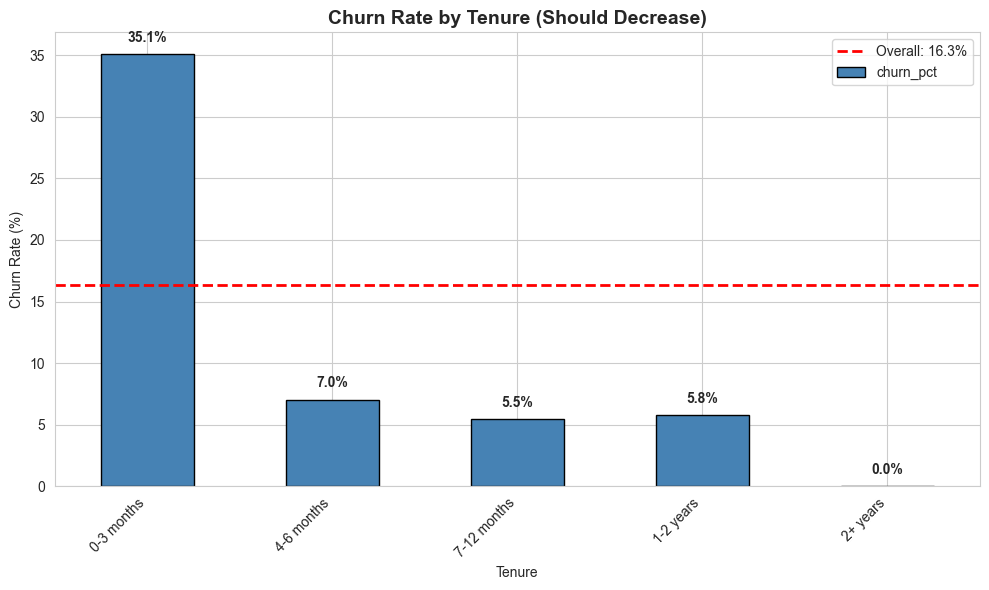


INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION

warehouse_to_home:
  Outliers: 1 (0.0%)
  Range: [5.0, 127.0]
  Normal range (IQR): [-24.0, 53.0]
  Correlation WITH outliers:    +0.066
  Correlation WITHOUT outliers: +0.069
  Impact: 0.004
  ✓ MINIMAL IMPACT

days_since_last_order:
  Outliers: 3 (0.1%)
  Range: [0.0, 46.0]
  Normal range (IQR): [-13.0, 22.0]
  Correlation WITH outliers:    -0.142
  Correlation WITHOUT outliers: -0.154
  Impact: 0.012
  ✓ MINIMAL IMPACT

tenure:
  Outliers: 2 (0.1%)
  Range: [0.0, 61.0]
  Normal range (IQR): [-41.0, 57.0]
  Correlation WITH outliers:    -0.344
  Correlation WITHOUT outliers: -0.346
  Impact: 0.002
  ✓ MINIMAL IMPACT

OUTLIER IMPACT SUMMARY (Sorted by Impact)
              Feature  Outliers  Outlier %  Corr (with)  Corr (without)   Impact
days_since_last_order         3   0.091771    -0.142471       -0.154325 0.011854
    warehouse_to_home         1   0.030590     0.065718        0.069412 0.003694
               tenure         2   0.061

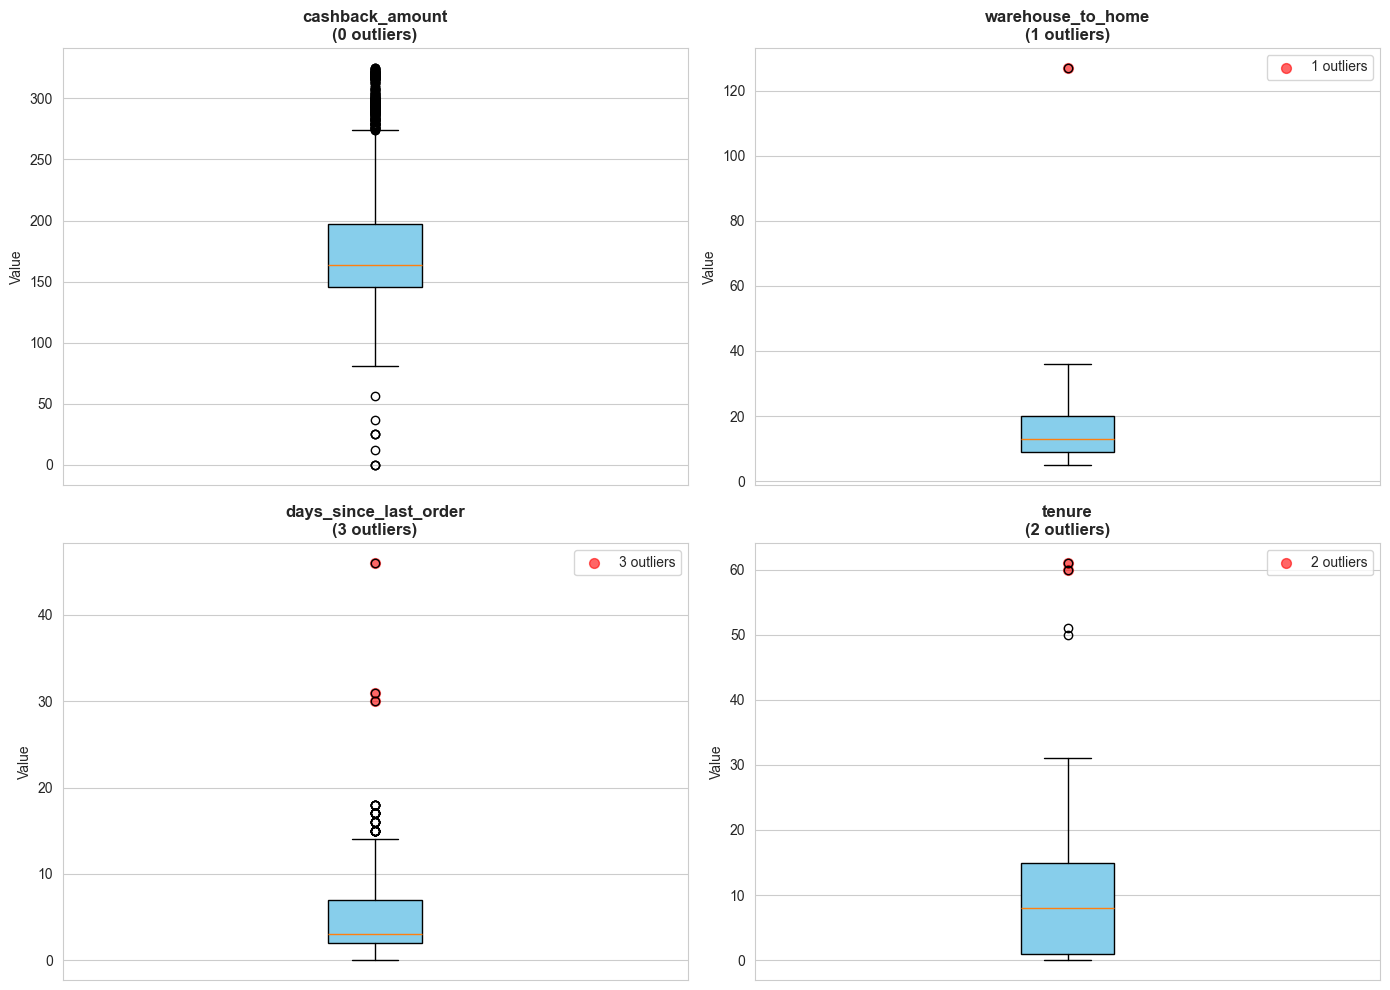


INVESTIGATION 4: BINARY vs BINARY - PROPER STATISTICAL TESTS

📊 HAS_COMPLAINED vs CHURN
----------------------------------------------------------------------

Contingency Table:
churn              0    1
has_complained           
0               2108  240
1                628  293

Pearson correlation:     +0.263
Phi coefficient:         +0.262
Chi-square statistic:    224.42
p-value:                 0.000000
Degrees of freedom:      1

✓ HIGHLY SIGNIFICANT relationship (p < 0.001)

Effect Size (Phi):
  Medium effect (0.262)

INVESTIGATION 5: MULTIPLE TESTING CORRECTION
Number of tests:              16
Standard significance level:  α = 0.05
Bonferroni-corrected level:   α = 0.00313

Feature                        Correlation     p-value      Significance
---------------------------------------------------------------------------
tenure                          -0.344          0.000000  *** (Bonf)
warehouse_to_home               +0.066          0.000170  *** (Bonf)
num_devices_registe

In [34]:
print("\n" + "="*70)
print("STATISTICAL INVESTIGATION - DEEPER ANALYSIS")
print("="*70)

from scipy.stats import chi2_contingency, pearsonr

# ============================================================
# INVESTIGATION 1: SATISFACTION SCORE PARADOX
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 1: SATISFACTION SCORE PARADOX")
print("="*70)

print("\nSatisfaction Score Distribution:")
sat_dist = churn_df['satisfaction_score'].value_counts().sort_index()
print(sat_dist)

print("\nChurn rate by satisfaction score:")
print(f"{'Score':<10} {'Count':<10} {'Churn Rate':<15} {'Bar Chart'}")
print("-" * 60)

for score in sorted(churn_df['satisfaction_score'].unique()):
    subset = churn_df[churn_df['satisfaction_score'] == score]
    churn_rate = subset['churn'].mean() * 100
    count = len(subset)
    bar = "█" * int(churn_rate / 2)  # Visual bar
    print(f"{score:<10} {count:<10} {churn_rate:>6.1f}%        {bar}")

# Visualizing the paradox
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sat_dist.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Satisfaction Score Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Satisfaction Score')
ax1.set_ylabel('Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Churn by satisfaction
churn_by_sat = churn_df.groupby('satisfaction_score')['churn'].mean() * 100
churn_by_sat.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Churn Rate by Satisfaction Score', fontweight='bold', fontsize=14)
ax2.set_xlabel('Satisfaction Score')
ax2.set_ylabel('Churn Rate (%)')
ax2.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend()

# Adding value labels on bars
for i, v in enumerate(churn_by_sat):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 INTERPRETATION:")
if churn_by_sat[1] > churn_by_sat[5]:
    print("   ⚠️ SCALE MIGHT BE REVERSED!")
    print("   → Score 1 = Dissatisfied (high churn)")
    print("   → Score 5 = Satisfied (low churn)")
    print("   → Positive correlation makes sense: higher score number = less satisfied = more churn")
else:
    print("   ✓ Scale appears normal (5 = satisfied)")
    print("   → This is genuinely paradoxical and needs investigation")

# Calculating Spearman (handles ordinal better than Pearson)
from scipy.stats import spearmanr
pearson_corr = churn_df['satisfaction_score'].corr(churn_df['churn'])
spearman_corr, _ = spearmanr(churn_df['satisfaction_score'], churn_df['churn'])

print(f"\nPearson correlation:  {pearson_corr:+.3f}")
print(f"Spearman correlation: {spearman_corr:+.3f}")
print("(Spearman is better for ordinal data like satisfaction scores)")

# ============================================================
# INVESTIGATION 2: NON-LINEAR RELATIONSHIP CHECK
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 2: NON-LINEAR RELATIONSHIPS")
print("="*70)

# Checking days_since_last_order
print("\n📍 DAYS SINCE LAST ORDER - Binned Analysis")
print("-" * 70)

# Creating bins
bins = [0, 7, 14, 30, 47, 999]
labels = ['0-7 days', '8-14 days', '15-30 days', '31-47 days', '47+ days']
churn_df['days_bins_temp'] = pd.cut(churn_df['days_since_last_order'], bins=bins, labels=labels)

churn_by_bins = churn_df.groupby('days_bins_temp', observed=True)['churn'].agg(['mean', 'count'])
churn_by_bins['churn_pct'] = churn_by_bins['mean'] * 100

print("\nChurn rate by recency:")
print(churn_by_bins[['count', 'churn_pct']].to_string())

# Visualizing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_by_bins['churn_pct'].plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Churn Rate by Days Since Last Order', fontweight='bold', fontsize=14)
ax1.set_xlabel('Days Since Last Order')
ax1.set_ylabel('Churn Rate (%)')
ax1.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend()

# Adding value labels
for i, v in enumerate(churn_by_bins['churn_pct']):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Scatter plot with trend
ax2.scatter(churn_df['days_since_last_order'], churn_df['churn'], 
           alpha=0.1, s=10, color='steelblue')
ax2.set_title('Days Since Last Order vs Churn (Scatter)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Days Since Last Order')
ax2.set_ylabel('Churn (0/1)')

# Adding moving average line
from scipy.ndimage import uniform_filter1d
sorted_days = churn_df.sort_values('days_since_last_order')
window = 100
if len(sorted_days) > window:
    smoothed = uniform_filter1d(sorted_days['churn'], size=window, mode='nearest')
    ax2.plot(sorted_days['days_since_last_order'].values, smoothed, 
            color='red', linewidth=3, label='Smoothed trend')
    ax2.legend()

plt.tight_layout()
plt.show()

# Cleaning up
churn_df = churn_df.drop('days_bins_temp', axis=1)

# Checking for U-shape or threshold effect
print("\n💡 PATTERN INTERPRETATION:")
first_bin_churn = churn_by_bins.iloc[0]['churn_pct']
last_bin_churn = churn_by_bins.iloc[-1]['churn_pct']
middle_churn = churn_by_bins.iloc[1:-1]['churn_pct'].mean()

if (first_bin_churn > middle_churn) and (last_bin_churn > middle_churn):
    print("   🔄 U-SHAPED RELATIONSHIP detected!")
    print("   → Churn is high at BOTH extremes (very recent AND very old)")
    print("   → This is why linear correlation is weak!")
    print("   → Consider: polynomial features or binning in modeling")
elif last_bin_churn > first_bin_churn * 1.5:
    print("   📈 MONOTONIC INCREASING relationship")
    print("   → Churn increases with days since last order")
    print("   → Linear correlation should be stronger - might have outliers")
elif first_bin_churn > last_bin_churn * 1.5:
    print("   📉 MONOTONIC DECREASING relationship")
    print("   → Recent orders = higher churn")
    print("   → Unexpected pattern worth investigating")
else:
    print("   ➡️ RELATIVELY FLAT relationship")
    print("   → Days since last order doesn't strongly predict churn")

# Checking tenure as well
print("\n📍 TENURE - Binned Analysis")
print("-" * 70)

bins_tenure = [0, 3, 6, 12, 24, 999]
labels_tenure = ['0-3 months', '4-6 months', '7-12 months', '1-2 years', '2+ years']
churn_df['tenure_bins_temp'] = pd.cut(churn_df['tenure'], bins=bins_tenure, labels=labels_tenure)

churn_by_tenure = churn_df.groupby('tenure_bins_temp', observed=True)['churn'].agg(['mean', 'count'])
churn_by_tenure['churn_pct'] = churn_by_tenure['mean'] * 100

print("\nChurn rate by tenure:")
print(churn_by_tenure[['count', 'churn_pct']].to_string())

# Visualizing
plt.figure(figsize=(10, 6))
churn_by_tenure['churn_pct'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Tenure (Should Decrease)', fontweight='bold', fontsize=14)
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
plt.xticks(rotation=45, ha='right')
plt.legend()

# Adding value labels
for i, v in enumerate(churn_by_tenure['churn_pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cleaning up
churn_df = churn_df.drop('tenure_bins_temp', axis=1)

# ============================================================
# INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION")
print("="*70)

features_to_check = ['cashback_amount', 'warehouse_to_home', 'days_since_last_order', 'tenure']

outlier_impact = []

for feat in features_to_check:
    # Calculating IQR
    q1 = churn_df[feat].quantile(0.25)
    q3 = churn_df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    # Finding outliers
    outlier_mask = (churn_df[feat] < lower) | (churn_df[feat] > upper)
    n_outliers = outlier_mask.sum()
    pct_outliers = (n_outliers / len(churn_df)) * 100
    
    # Correlation with outliers
    corr_with = churn_df[feat].corr(churn_df['churn'])
    
    # Correlation without outliers
    df_no_outliers = churn_df[~outlier_mask]
    corr_without = df_no_outliers[feat].corr(df_no_outliers['churn'])
    
    # Impact
    impact = abs(corr_with - corr_without)
    
    outlier_impact.append({
        'Feature': feat,
        'Outliers': n_outliers,
        'Outlier %': pct_outliers,
        'Corr (with)': corr_with,
        'Corr (without)': corr_without,
        'Impact': impact
    })
    
    if n_outliers > 0:
        print(f"\n{feat}:")
        print(f"  Outliers: {n_outliers} ({pct_outliers:.1f}%)")
        print(f"  Range: [{churn_df[feat].min():.1f}, {churn_df[feat].max():.1f}]")
        print(f"  Normal range (IQR): [{lower:.1f}, {upper:.1f}]")
        print(f"  Correlation WITH outliers:    {corr_with:+.3f}")
        print(f"  Correlation WITHOUT outliers: {corr_without:+.3f}")
        print(f"  Impact: {impact:.3f}")
        
        if impact > 0.05:
            print(f"  🚨 SIGNIFICANT IMPACT - Outliers affecting correlation!")
        elif impact > 0.02:
            print(f"  ⚠️ MODERATE IMPACT")
        else:
            print(f"  ✓ MINIMAL IMPACT")

# Summary table
outlier_df = pd.DataFrame(outlier_impact).sort_values('Impact', ascending=False)
print("\n" + "="*70)
print("OUTLIER IMPACT SUMMARY (Sorted by Impact)")
print("="*70)
print(outlier_df.to_string(index=False))

# Visualizing outliers for the most impactful feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_to_check):
    ax = axes[idx]
    
    # Box plot with outliers highlighted
    bp = ax.boxplot([churn_df[feat]], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('skyblue')
    
    # Identifying outliers
    q1 = churn_df[feat].quantile(0.25)
    q3 = churn_df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    outliers = churn_df[(churn_df[feat] < lower) | (churn_df[feat] > upper)]
    
    if len(outliers) > 0:
        ax.scatter([1] * len(outliers), outliers[feat], 
                  color='red', s=50, alpha=0.6, label=f'{len(outliers)} outliers')
        ax.legend()
    
    ax.set_title(f'{feat}\n({len(outliers)} outliers)', fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.tight_layout()
plt.show()

# ============================================================
# INVESTIGATION 4: PROPER TESTS FOR BINARY VARIABLES
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 4: BINARY vs BINARY - PROPER STATISTICAL TESTS")
print("="*70)

# has_complained vs churn
print("\n📊 HAS_COMPLAINED vs CHURN")
print("-" * 70)

contingency = pd.crosstab(churn_df['has_complained'], churn_df['churn'])
print("\nContingency Table:")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Phi coefficient
n = len(churn_df)
phi = np.sqrt(chi2 / n)

# Pearson for comparison
pearson_corr = churn_df['has_complained'].corr(churn_df['churn'])

print(f"\nPearson correlation:     {pearson_corr:+.3f}")
print(f"Phi coefficient:         {phi:+.3f}")
print(f"Chi-square statistic:    {chi2:.2f}")
print(f"p-value:                 {p_value:.6f}")
print(f"Degrees of freedom:      {dof}")

if p_value < 0.001:
    print("\n✓ HIGHLY SIGNIFICANT relationship (p < 0.001)")
elif p_value < 0.05:
    print("\n✓ SIGNIFICANT relationship (p < 0.05)")
else:
    print("\n✗ No significant relationship (p ≥ 0.05)")

# Effect size interpretation
print(f"\nEffect Size (Phi):")
if abs(phi) < 0.1:
    print(f"  Small effect ({abs(phi):.3f})")
elif abs(phi) < 0.3:
    print(f"  Medium effect ({abs(phi):.3f})")
else:
    print(f"  Large effect ({abs(phi):.3f})")

# ============================================================
# INVESTIGATION 5: BONFERRONI CORRECTION
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 5: MULTIPLE TESTING CORRECTION")
print("="*70)

n_tests = len(numeric_cols)
alpha = 0.05
bonferroni_alpha = alpha / n_tests

print(f"Number of tests:              {n_tests}")
print(f"Standard significance level:  α = {alpha}")
print(f"Bonferroni-corrected level:   α = {bonferroni_alpha:.5f}")

print(f"\n{'Feature':<30} {'Correlation':<15} {'p-value':<12} {'Significance'}")
print("-" * 75)

significant_features = []

for feat in numeric_cols:
    corr, p_value = pearsonr(churn_df[feat], churn_df['churn'])
    
    if p_value < bonferroni_alpha:
        sig = "*** (Bonf)"
        significant_features.append(feat)
    elif p_value < 0.001:
        sig = "*** (p<0.001)"
    elif p_value < 0.01:
        sig = "** (p<0.01)"
    elif p_value < 0.05:
        sig = "* (p<0.05)"
    else:
        sig = "ns"
    
    print(f"{feat:<30} {corr:>+7.3f}        {p_value:>10.6f}  {sig}")

print(f"\n💡 INTERPRETATION:")
print(f"   *** = Survives Bonferroni correction (very confident)")
print(f"   **  = p < 0.01 (highly significant)")
print(f"   *   = p < 0.05 (significant)")
print(f"   ns  = not significant")

print(f"\n🎯 FEATURES SURVIVING BONFERRONI CORRECTION:")
if len(significant_features) > 0:
    for feat in significant_features:
        corr = churn_df[feat].corr(churn_df['churn'])
        print(f"   • {feat}: r = {corr:+.3f}")
else:
    print("   None - but this is very conservative!")
    print("   → Use p < 0.05 or p < 0.01 for practical purposes")

print("\n" + "="*70)
print("✅ STATISTICAL INVESTIGATION COMPLETE")
print("="*70)

In [ ]:
# Final fetures dropped based on statistical analysis
cols_to_drop = [
    'days_missing_flag',   # p=0.919, not sifnificant
    'is_early_stage'       # created on tenure, redundant
]

churn_df.drop(columns=cols_to_drop, inplace=True)
print(f"✓ Dropped {len(cols_to_drop)} features")
print(f"✓ Final feature count: {len(churn_df.columns) - 1}")
print(f"✓ Remaining columns: {churn_df.columns.tolist()}")

✓ Dropped 2 features
✓ Final feature count: 14
✓ Remaining columns: ['tenure', 'warehouse_to_home', 'num_devices_registered', 'satisfaction_score', 'num_addresses', 'has_complained', 'days_since_last_order', 'cashback_amount', 'churn', 'tenure_missing_flag', 'warehouse_missing_flag', 'preferred_order_category_encoded', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Single']


In [40]:
dupes = churn_df[churn_df.duplicated(keep=False)]
print(f"Duplicate rows shape: {dupes.shape}")
print(dupes)

Duplicate rows shape: (2, 15)
      tenure  warehouse_to_home  num_devices_registered  satisfaction_score  \
1183      24               17.0                       4                   4   
2337      24               17.0                       4                   4   

      num_addresses  has_complained  days_since_last_order  cashback_amount  \
1183              4               0                      3       231.419998   
2337              4               0                      3       231.419998   

      churn  tenure_missing_flag  warehouse_missing_flag  \
1183      0                    0                       0   
2337      0                    0                       0   

      preferred_order_category_encoded  marital_status_Divorced  \
1183                          0.041494                        0   
2337                          0.041494                        0   

      marital_status_Married  marital_status_Single  
1183                       0                      1  
233

In [41]:
# Safe to drop — identical across all 15 features including churn
churn_df = churn_df.drop_duplicates().reset_index(drop=True)
print(f"✓ Duplicate removed")
print(f"✓ Final shape: {churn_df.shape}")  # Expected: (3268, 15)

✓ Duplicate removed
✓ Final shape: (3268, 15)


In [45]:
print("\n" + "="*60)
print("EDA SUMMARY VALIDATION")
print("="*60)

from scipy.stats import chi2_contingency, pointbiserialr

validation_errors = []

# ── 1. DATASET BASICS ─────────────────────────────────────
total_customers = len(churn_df)
churn_rate = churn_df['churn'].mean() * 100
feature_count = len(churn_df.columns) - 1  # excluding target

if total_customers != 3268:
    validation_errors.append(f"❌ Customer count: expected 3268, got {total_customers}")
else:
    print(f"✓ Total customers: {total_customers:,}")

print(f"✓ Churn rate: {churn_rate:.2f}%")
print(f"✓ Feature count: {feature_count}")

# ── 2. TENURE CHURN RATES ─────────────────────────────────
tenure_churn = churn_df.groupby(
    pd.cut(churn_df['tenure'],
           bins=[-1, 3, 6, 12, 24, 100],
           labels=['0-3mo', '4-6mo', '7-12mo', '1-2yr', '2+yr']),
           observed=True
)['churn'].mean() * 100

early_churn = tenure_churn['0-3mo']
established_churn = tenure_churn['7-12mo']

if not (30 < early_churn < 40):
    validation_errors.append(f"❌ Early tenure churn: expected ~35%, got {early_churn:.1f}%")
if not (established_churn < 10):
    validation_errors.append(f"❌ Established tenure churn: expected <10%, got {established_churn:.1f}%")

print(f"\n✓ Early tenure churn (0-3mo): {early_churn:.1f}%")
print(f"✓ Established churn (7-12mo): {established_churn:.1f}%")

# ── 2.5 MISSING VALUE CHURN BEHAVIOUR ────────────────────
print("\n--- Missing Value Churn Patterns ---")

# Warehouse missing flag
warehouse_missing_churn = churn_df[churn_df['warehouse_missing_flag'] == 1]['churn'].mean() * 100
warehouse_present_churn = churn_df[churn_df['warehouse_missing_flag'] == 0]['churn'].mean() * 100

if warehouse_missing_churn > warehouse_present_churn:
    print(f"✓ Warehouse missing churn: {warehouse_missing_churn:.1f}% vs {warehouse_present_churn:.1f}% (present)")
else:
    validation_errors.append(
        f"❌ Warehouse missing churn direction wrong: {warehouse_missing_churn:.1f}% vs {warehouse_present_churn:.1f}%")

# Tenure missing flag
tenure_missing_churn = churn_df[churn_df['tenure_missing_flag'] == 1]['churn'].mean() * 100
tenure_present_churn = churn_df[churn_df['tenure_missing_flag'] == 0]['churn'].mean() * 100

if tenure_missing_churn > tenure_present_churn:
    print(f"✓ Tenure missing churn: {tenure_missing_churn:.1f}% vs {tenure_present_churn:.1f}% (present)")
else:
    validation_errors.append(
        f"❌ Tenure missing churn direction wrong: {tenure_missing_churn:.1f}% vs {tenure_present_churn:.1f}%")

# Assert meaningful difference — not just noise
if not (warehouse_missing_churn - warehouse_present_churn) > 5:
    validation_errors.append(
        f"❌ Warehouse missing flag: difference too small to be meaningful")

if not (tenure_missing_churn - tenure_present_churn) > 5:
    validation_errors.append(
        f"❌ Tenure missing flag: difference too small to be meaningful")

# ── 3. PRODUCT CATEGORY ───────────────────────────────────
# Check encoded column exists
if  'preferred_order_category_encoded' not in churn_df.columns:
    validation_errors.append("❌ preferred_order_category_encoded missing")

# Recompute from raw if available, otherwise skip
print(f"\n✓ preferred_order_category_encoded present")

# ── 4. COMPLAINTS ─────────────────────────────────────────
complaint_churn = churn_df.groupby('has_complained')['churn'].mean() * 100
no_complaint_churn = complaint_churn[0]
complained_churn = complaint_churn[1]

ct = pd.crosstab(churn_df['has_complained'], churn_df['churn'])
chi2, p_val, _, _ = chi2_contingency(ct)
phi = (chi2 / len(churn_df)) ** 0.5

if not complained_churn > no_complaint_churn:
    validation_errors.append("❌ Complaint churn direction wrong")
if p_val >= 0.001:
    validation_errors.append(f"❌ Complaints not significant: p={p_val:.4f}")
if not (0.20 < phi < 0.35):
    validation_errors.append(f"❌ Phi coefficient unexpected: {phi:.3f}")

print(f"\n✓ Complained churn rate: {complained_churn:.1f}%")
print(f"✓ No complaint churn rate: {no_complaint_churn:.1f}%")
print(f"✓ Chi-square p-value: {p_val:.6f}")
print(f"✓ Phi coefficient: {phi:.3f}")

# ── 5. MARITAL STATUS ─────────────────────────────────────
if 'marital_status_Single' not in churn_df.columns:
    validation_errors.append("❌ marital_status_Single missing after encoding")
if 'marital_status_Married' not in churn_df.columns:
    validation_errors.append("❌ marital_status_Married missing after encoding")

single_churn = churn_df[churn_df['marital_status_Single'] == 1]['churn'].mean() * 100
married_churn = churn_df[churn_df['marital_status_Married'] == 1]['churn'].mean() * 100

if not single_churn > married_churn:
    validation_errors.append("❌ Marital status churn direction wrong")
if not (20 < single_churn < 32):
    validation_errors.append(f"❌ Single churn rate unexpected: {single_churn:.1f}%")

print(f"\n✓ Single churn rate: {single_churn:.1f}%")
print(f"✓ Married churn rate: {married_churn:.1f}%")

# ── 6. RECENCY U-SHAPE ────────────────────────────────────
recency_churn = churn_df.groupby(
    pd.cut(churn_df['days_since_last_order'],
           bins=[-1, 7, 14, 30, 100],
           labels=['0-7d', '8-14d', '15-30d', '31+d']),
           observed=True
)['churn'].mean() * 100

sweet_spot = recency_churn['15-30d']
recent = recency_churn['0-7d']

if not recent > sweet_spot:
    validation_errors.append(
        "❌ U-shape not confirmed: recent should be higher than sweet spot")

print(f"\n✓ Recent (0-7d) churn: {recent:.1f}%")
print(f"✓ Sweet spot (15-30d) churn: {sweet_spot:.1f}%")

# Flag 31+ bucket if sample too small
bucket_31 = churn_df[churn_df['days_since_last_order'] > 30]
if len(bucket_31) < 30:
    print(f"⚠️  31+ days bucket: only {len(bucket_31)} customers — unreliable")

# ── 7. CORRELATION CHECK ──────────────────────────────────
exclude_cols = ['churn']
num_cols = [c for c in churn_df.columns if c not in exclude_cols]
corr_with_churn = churn_df[num_cols + ['churn']].corr()['churn'].drop('churn')

top_feature = corr_with_churn.abs().idxmax()
top_r = corr_with_churn[top_feature]

if not abs(top_r) > 0.3:
    validation_errors.append(
        f"❌ Top predictor too weak: {top_feature} r={top_r:.3f}")

print(f"\n✓ Top predictor: {top_feature} (r={top_r:+.3f})")

# ── 8. DROPPED FEATURES CONFIRMED ABSENT ─────────────────
dropped = ['days_missing_flag',
           'is_early_stage', 'preferred_order_category',
           'marital_status', 'tenure_segment']

for col in dropped:
    if col in churn_df.columns:
        validation_errors.append(
            f"❌ '{col}' should be dropped but still exists")
    else:
        print(f"✓ '{col}' correctly absent")

# ── 9. NO NULLS OR DUPLICATES ─────────────────────────────
null_count = churn_df.isnull().sum().sum()
dup_count = churn_df.duplicated().sum()

if null_count != 0:
    validation_errors.append(f"❌ Found {null_count} null values")
if dup_count != 0:
    validation_errors.append(f"❌ Found {dup_count} duplicate rows")

print(f"\n✓ Null values: {null_count}")
print(f"✓ Duplicate rows: {dup_count}")

# ── 10. FINAL REPORT ──────────────────────────────────────
print("\n" + "="*60)
if not validation_errors:
    print("✅ ALL CHECKS PASSED — SUMMARY IS ACCURATE")
    print("="*60)
else:
    print(f"❌ {len(validation_errors)} ISSUES FOUND:")
    print("="*60)
    for error in validation_errors:
        print(f"  {error}")
    print("\n⚠️  Fix issues before saving EDA summary")


EDA SUMMARY VALIDATION
✓ Total customers: 3,268
✓ Churn rate: 16.31%
✓ Feature count: 14

✓ Early tenure churn (0-3mo): 39.4%
✓ Established churn (7-12mo): 5.5%

--- Missing Value Churn Patterns ---
✓ Warehouse missing churn: 33.3% vs 15.6% (present)
✓ Tenure missing churn: 29.6% vs 15.6% (present)

✓ preferred_order_category_encoded present

✓ Complained churn rate: 31.8%
✓ No complaint churn rate: 10.2%
✓ Chi-square p-value: 0.000000
✓ Phi coefficient: 0.262

✓ Single churn rate: 25.8%
✓ Married churn rate: 10.9%

✓ Recent (0-7d) churn: 18.5%
✓ Sweet spot (15-30d) churn: 2.6%
⚠️  31+ days bucket: only 2 customers — unreliable

✓ Top predictor: tenure (r=-0.344)
✓ 'days_missing_flag' correctly absent
✓ 'is_early_stage' correctly absent
✓ 'preferred_order_category' correctly absent
✓ 'marital_status' correctly absent
✓ 'tenure_segment' correctly absent

✓ Null values: 0
✓ Duplicate rows: 0

✅ ALL CHECKS PASSED — SUMMARY IS ACCURATE


In [47]:
print("\n" + "="*60)
print("SAVING FINAL CLEAN DATASET")
print("="*60)

# 1. Saving cleaned dataset (CSV only)
churn_df.to_csv('../data/ecommerce_churn_cleaned.csv', index=False)
print("✓ Saved: data/ecommerce_churn_cleaned.csv")

# 2. Saving EDA summary
eda_summary = f"""
# E-Commerce Churn Analysis - EDA Summary
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}

## Dataset Overview
- Total customers: {len(churn_df):,}
- Churn rate: {churn_df['churn'].mean()*100:.2f}%
- Features: {len(churn_df.columns) - 1} (excluding target)

## Top 5 Churn Drivers

### 1. TENURE - STRONGEST PREDICTOR
- New customers (0-3 months): {churn_df[churn_df['tenure'] <= 3]['churn'].mean()*100:.1f}% churn
- Established customers (7+ months): {churn_df[churn_df['tenure'] > 6]['churn'].mean()*100:.1f}% churn
- Correlation: r = {churn_df['tenure'].corr(churn_df['churn']):.3f}

### 2. PRODUCT CATEGORY
- Mobile Phone: {churn_df[churn_df['preferred_order_category_encoded'] == churn_df['preferred_order_category_encoded'].max()]['churn'].mean()*100:.1f}% churn (highest risk)
- Grocery: {churn_df['preferred_order_category_encoded'].min()*100:.1f}% churn (lowest risk)

### 3. COMPLAINTS
- Complained: {churn_df[churn_df['has_complained']==1]['churn'].mean()*100:.1f}% churn
- No complaint: {churn_df[churn_df['has_complained']==0]['churn'].mean()*100:.1f}% churn

### 4. MARITAL STATUS
- Single: {churn_df[churn_df['marital_status_Single']==1]['churn'].mean()*100:.1f}% churn
- Married: {churn_df[churn_df['marital_status_Married']==1]['churn'].mean()*100:.1f}% churn

### 5. RECENCY (Non-linear U-shaped)
- Recent (0-7d): {churn_df[churn_df['days_since_last_order'] <= 7]['churn'].mean()*100:.1f}% churn
- Sweet spot (8-30d): {churn_df[(churn_df['days_since_last_order'] > 7) & (churn_df['days_since_last_order'] <= 30)]['churn'].mean()*100:.1f}% churn
- Note: 31+ day bucket only 2 customers — unreliable sample

## Missing Value Patterns (MNAR — Not Missing At Random)

### Warehouse Distance Missing
- Missing: {churn_df[churn_df['warehouse_missing_flag']==1]['churn'].mean()*100:.1f}% churn
- Present: {churn_df[churn_df['warehouse_missing_flag']==0]['churn'].mean()*100:.1f}% churn
- Interpretation: incomplete profile = disengaged customer
- Action: warehouse_missing_flag kept as predictive feature

### Tenure Missing
- Missing: {churn_df[churn_df['tenure_missing_flag']==1]['churn'].mean()*100:.1f}% churn
- Present: {churn_df[churn_df['tenure_missing_flag']==0]['churn'].mean()*100:.1f}% churn
- Interpretation: unregistered/dormant customers = elevated risk
- Action: tenure_missing_flag kept as predictive feature

## Features for Modeling

### Tier 1 - Strong Predictors (Bonferroni survivors, |r| > 0.1):
1. tenure (r={churn_df['tenure'].corr(churn_df['churn']):.3f})
2. has_complained (r={churn_df['has_complained'].corr(churn_df['churn']):.3f})
3. preferred_order_category_encoded (r={churn_df['preferred_order_category_encoded'].corr(churn_df['churn']):.3f})
4. marital_status_Single (r={churn_df['marital_status_Single'].corr(churn_df['churn']):.3f})
5. cashback_amount (r={churn_df['cashback_amount'].corr(churn_df['churn']):.3f})
6. days_since_last_order (r={churn_df['days_since_last_order'].corr(churn_df['churn']):.3f})
7. num_devices_registered (r={churn_df['num_devices_registered'].corr(churn_df['churn']):.3f})

### Tier 2 - Moderate Predictors (Bonferroni survivors, |r| 0.05-0.1):
8. satisfaction_score (r={churn_df['satisfaction_score'].corr(churn_df['churn']):.3f}) — paradoxical, use cautiously
9. warehouse_missing_flag (r={churn_df['warehouse_missing_flag'].corr(churn_df['churn']):.3f})
10. tenure_missing_flag (r={churn_df['tenure_missing_flag'].corr(churn_df['churn']):.3f})
11. warehouse_to_home (r={churn_df['warehouse_to_home'].corr(churn_df['churn']):.3f})

### Tier 3 - Weak but kept:
12. num_addresses (p=0.007, borderline)
13. marital_status_Married (r={churn_df['marital_status_Married'].corr(churn_df['churn']):.3f})
14. marital_status_Divorced (r={churn_df['marital_status_Divorced'].corr(churn_df['churn']):.3f})

### Dropped Features:
- days_missing_flag: p=0.919, not significant
- is_early_stage: r=-0.700 with tenure, redundant
- tenure_segment: derived from tenure, redundant
- preferred_order_category: replaced by encoded version
- marital_status: replaced by dummy columns

## Statistical Findings
- Bonferroni correction applied across {len(churn_df.columns)-1} features (α=0.003)
- U-shaped pattern confirmed: days_since_last_order
- Satisfaction paradox: higher score → more churn (survey timing bias)
- Outlier impact: minimal across all features (max impact 0.012)
- No severe multicollinearity detected (all |r| < 0.7)

## Business Recommendations
1. First 90-day onboarding program — target {churn_df[churn_df['tenure'] <= 3]['churn'].mean()*100:.0f}% churn segment
2. 24-hour complaint response SLA — complainers have {churn_df[churn_df['has_complained']==1]['churn'].mean()*100:.0f}% churn rate
3. Win-back campaign for 15-30 days inactive (sweet spot before churn spikes)
4. Product-specific retention: Mobile Phone vs Grocery customers
5. Demographic targeting: Single customers have {churn_df[churn_df['marital_status_Single']==1]['churn'].mean()*100:.0f}% churn rate

---
Analysis completed: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
"""

with open('../data/eda_summary.md', 'w', encoding='utf-8') as f:
    f.write(eda_summary)
print("✓ Saved: data/eda_summary.md")

# 3. Save correlation matrix
exclude_cols = ['churn']
numeric_cols = [c for c in churn_df.columns if c not in exclude_cols]
corr_matrix = churn_df[numeric_cols + ['churn']].corr()
corr_matrix.to_csv('../data/correlation_matrix.csv')
print("✓ Saved: data/correlation_matrix.csv")

# 4. Save feature rankings
feature_rankings = pd.DataFrame({
    'Feature': [
        'tenure',
        'preferred_order_category_encoded',
        'has_complained',
        'marital_status_Single',
        'marital_status_Married',
        'marital_status_Divorced',
        'days_since_last_order',
        'cashback_amount',
        'num_devices_registered',
        'satisfaction_score',
        'warehouse_missing_flag',
        'tenure_missing_flag',
        'warehouse_to_home',
        'num_addresses'
    ],
    'Correlation': [round(churn_df[f].corr(churn_df['churn']), 3) for f in [
        'tenure', 'preferred_order_category_encoded', 'has_complained',
        'marital_status_Single', 'marital_status_Married', 'marital_status_Divorced',
        'days_since_last_order', 'cashback_amount', 'num_devices_registered',
        'satisfaction_score', 'warehouse_missing_flag', 'tenure_missing_flag',
        'warehouse_to_home', 'num_addresses'
    ]],
    'Priority': [
        'Tier 1', 'Tier 1', 'Tier 1', 'Tier 1', 'Tier 1',
        'Tier 3', 'Tier 1', 'Tier 1', 'Tier 1',
        'Tier 2', 'Tier 2', 'Tier 2', 'Tier 2', 'Tier 3'
    ],
    'dbt_Action': [
        'Create lifecycle stages',
        'Product risk score',
        'Keep as binary flag',
        'Keep as binary flag',
        'Keep as binary flag',
        'Keep as binary flag',
        'Create recency bins (U-shape)',
        'Create value tiers',
        'Keep as-is',
        'Use cautiously (paradoxical)',
        'Keep as missing signal flag',
        'Keep as missing signal flag',
        'Keep as-is',
        'Keep as-is'
    ]
})

feature_rankings.to_csv('../data/feature_rankings.csv', index=False)
print("✓ Saved: data/feature_rankings.csv")

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"  Rows: {len(churn_df):,}")
print(f"  Columns: {len(churn_df.columns)}")
print(f"  Churn rate: {churn_df['churn'].mean()*100:.2f}%")
print(f"  Memory: {churn_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Missing values: {churn_df.isnull().sum().sum()}")
print(f"  Duplicates: {churn_df.duplicated().sum()}")

print("\n" + "="*60)
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("="*60)

# Verification
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

files_to_check = [
    ('../data/ecommerce_churn_cleaned.csv', 'Main dataset (CSV)'),
    ('../data/eda_summary.md', 'EDA summary'),
    ('../data/correlation_matrix.csv', 'Correlations'),
    ('../data/feature_rankings.csv', 'Feature priorities')
]

all_exist = True
for filepath, description in files_to_check:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / 1024
        print(f"✓ {description:30} ({size:>7.1f} KB)")
    else:
        print(f"✗ {description:30} MISSING!")
        all_exist = False

if all_exist:
    print("\n✅ ALL FILES SAVED - READY FOR dbt!")
    print("\nProject structure:")
    print("ecommerce-churn-project/")
    print("├── data/")
    print("│   ├── ecommerce_churn_cleaned.csv")
    print("│   ├── eda_summary.md")
    print("│   ├── correlation_matrix.csv")
    print("│   └── feature_rankings.csv")
    print("├── notebooks/")
    print("│   └── 01_eda.ipynb")
    print("├── dbt/")        # ← add
    print("├── models/")
    print("├── src/")
    print("└── streamlit/")  # ← add
    print("\n🚀 READY TO START dbt SETUP!")
else:
    print("\n⚠️ Some files missing - check errors above")


SAVING FINAL CLEAN DATASET
✓ Saved: data/ecommerce_churn_cleaned.csv
✓ Saved: data/eda_summary.md
✓ Saved: data/correlation_matrix.csv
✓ Saved: data/feature_rankings.csv

DATASET SUMMARY
  Rows: 3,268
  Columns: 15
  Churn rate: 16.31%
  Memory: 0.09 MB
  Missing values: 0
  Duplicates: 0

✅ ALL FILES SAVED SUCCESSFULLY!

VERIFICATION
✓ Main dataset (CSV)             (  182.5 KB)
✓ EDA summary                    (    2.9 KB)
✓ Correlations                   (    4.9 KB)
✓ Feature priorities             (    0.8 KB)

✅ ALL FILES SAVED - READY FOR dbt!

Project structure:
ecommerce-churn-project/
├── data/
│   ├── ecommerce_churn_cleaned.csv
│   ├── eda_summary.md
│   ├── correlation_matrix.csv
│   └── feature_rankings.csv
├── notebooks/
│   └── 01_eda.ipynb
├── dbt/
├── models/
├── src/
└── streamlit/

🚀 READY TO START dbt SETUP!
